In [1]:
suppressPackageStartupMessages({
    library(ArchR) 
    library(data.table)
    library(purrr)
    library(parallel)
    library(dplyr)
    library(Matrix)
    library(SingleCellExperiment)
    library(Seurat)
    library(reshape2)
    library(scater)
    library(viridis)
    library(gridExtra)
    library(ggpubr)
})

options(repr.plot.width=15, repr.plot.height=8)
options(warn = -1)

Warning message:
“package ‘Seurat’ was built under R version 4.1.2”


In [2]:
# I/O
io = list()
io$basedir='/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2'
io$output.directory <- file.path(io$basedir,"ArchR")
io$plot.dir = file.path(io$output.directory,'Plots')
io$plot.trophoblast = file.path(io$plot.dir,'Trophoblast')

dir.create(file.path(io$plot.trophoblast), showWarnings = FALSE)


setwd(io$output.directory)

In [3]:
io$archR.directory = file.path(io$output.directory, 'Project/')
ArchRProject.filt = loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [5]:
unique(ArchRProject.filt@cellColData$sample)

[1] "rabbit_BGRGP1" "rabbit_BGRGP2" "rabbit_BGRGP3" "rabbit_BGRGP4"
[5] "rabbit_BGRGP5" "rabbit_BGRGP6" "rabbit_BGRGP7" "rabbit_BGRGP8"

In [4]:
names = rownames(getReducedDims((ArchRProject.filt)))
ArchRProject.filt@cellColData = ArchRProject.filt@cellColData[order(match(ArchRProject.filt@cellColData$cell, names)),]

In [5]:
unique(ArchRProject.filt@cellColData$celltype_manual)

[1] "Embryo_proper"           "Epiblast"               
 [3] "Trophoblast"             "Hypoblast"              
 [5] "Primitive_Streak"        "CYT"                    
 [7] "Megakaryocytes"          "Early_Amniotic_Ectoderm"
 [9] "Mesoderm"                "Endothelium"            
[11] "Erythrocytes"            "SCT"                    
[13] "Visceral_YS_Endoderm"

# Trophoblast Trajectory

In [6]:
trajectory <- c("Trophoblast", "CYT", "SCT")
trajectory

[1] "Trophoblast" "CYT"         "SCT"

In [7]:
ArchRProject.filt <- addTrajectory(
    ArchRProj = ArchRProject.filt, 
    name = "Tropho", 
    groupBy = "celltype_manual",
    trajectory = trajectory, 
    embedding = "UMAP", 
    force = TRUE
)

ArchR logging to : ArchRLogs/ArchR-addTrajectory-17e71277cc489-Date-2022-01-05_Time-14-09-24.log
If there is an issue, please report to github with logFile!

Filtering outliers

Initial Alignment Before Spline Fit

Spline Fit

KNN to Spline

ArchR logging successful to : ArchRLogs/ArchR-addTrajectory-17e71277cc489-Date-2022-01-05_Time-14-09-24.log



ArchR logging to : ArchRLogs/ArchR-plotTrajectory-16bf04ce49c3f-Date-2022-01-05_Time-11-27-12.log
If there is an issue, please report to github with logFile!

Plotting

Plotting Trajectory

Adding Inferred Arrow Trajectory to Plot

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectory-16bf04ce49c3f-Date-2022-01-05_Time-11-27-12.log



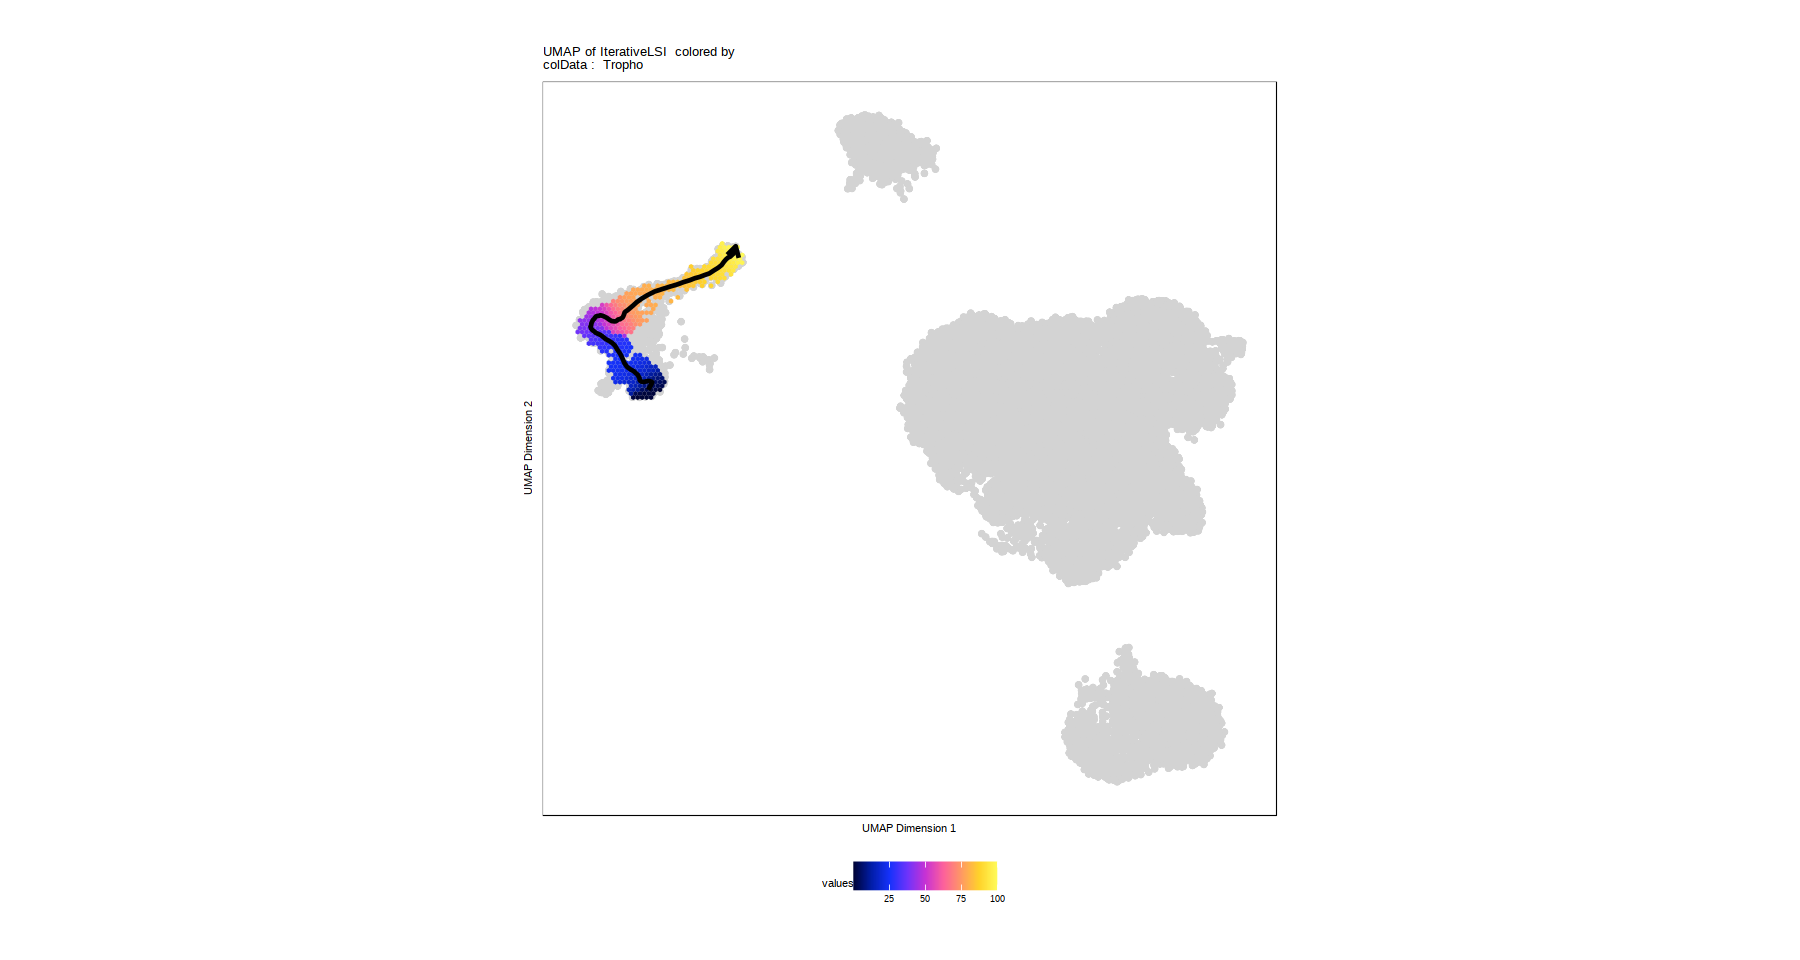

In [9]:
p <- plotTrajectory(ArchRProject.filt, trajectory = "Tropho", colorBy = "cellColData", name = "Tropho")
p[[1]]

In [414]:
getAvailableMatrices(ArchRProject.filt)

[1] "GeneIntegrationMatrix" "GeneScoreMatrix"       "MotifMatrix"          
[4] "PeakMatrix"            "TileMatrix"

In [183]:
getFeatures(ArchRProject.filt, select = 'GCM1', useMatrix = "MotifMatrix")


[1] "z:GCM1_390"          "deviations:GCM1_390"

In [13]:
ArchRProject.filt = addImputeWeights(ArchRProject.filt)

ArchR logging to : ArchRLogs/ArchR-addImputeWeights-15fd76463b71f-Date-2022-01-05_Time-10-53-31.log
If there is an issue, please report to github with logFile!

2022-01-05 10:53:31 : Computing Impute Weights Using Magic (Cell 2018), 0 mins elapsed.



Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotTrajectory-17e7167190a2e-Date-2022-01-05_Time-14-09-37.log
If there is an issue, please report to github with logFile!

Getting Matrix Values...

2022-01-05 14:10:07 : 

1 
2 
3 
4 
5 
6 
7 
8 


Imputing Matrix

Using weights on disk

1 of 7

2 of 7

3 of 7

4 of 7

5 of 7

6 of 7

7 of 7

Using weights on disk

1 of 7

2 of 7

3 of 7

4 of 7

5 of 7

6 of 7

7 of 7

Plotting

Plotting Trajectory

Adding Inferred Arrow Trajectory to Plot

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectory-17e7167190a2e-Date-2022-01-05_Time-14-09-37.log

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



[[1]]

[[2]]


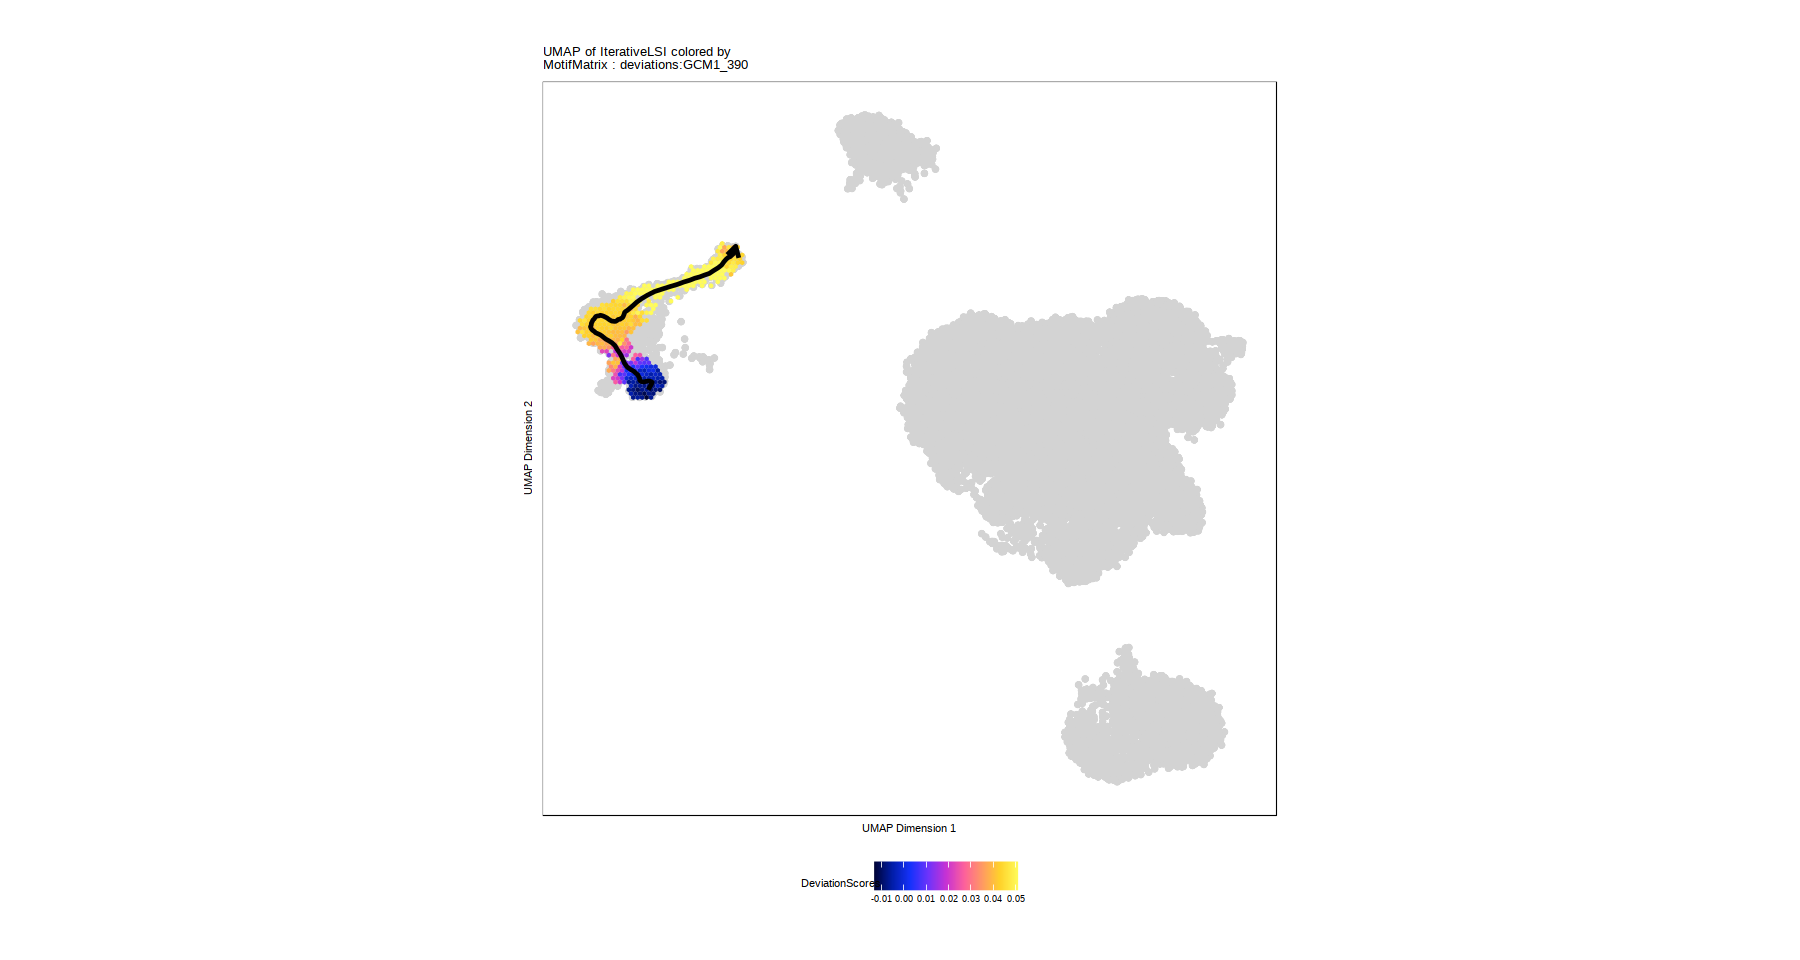

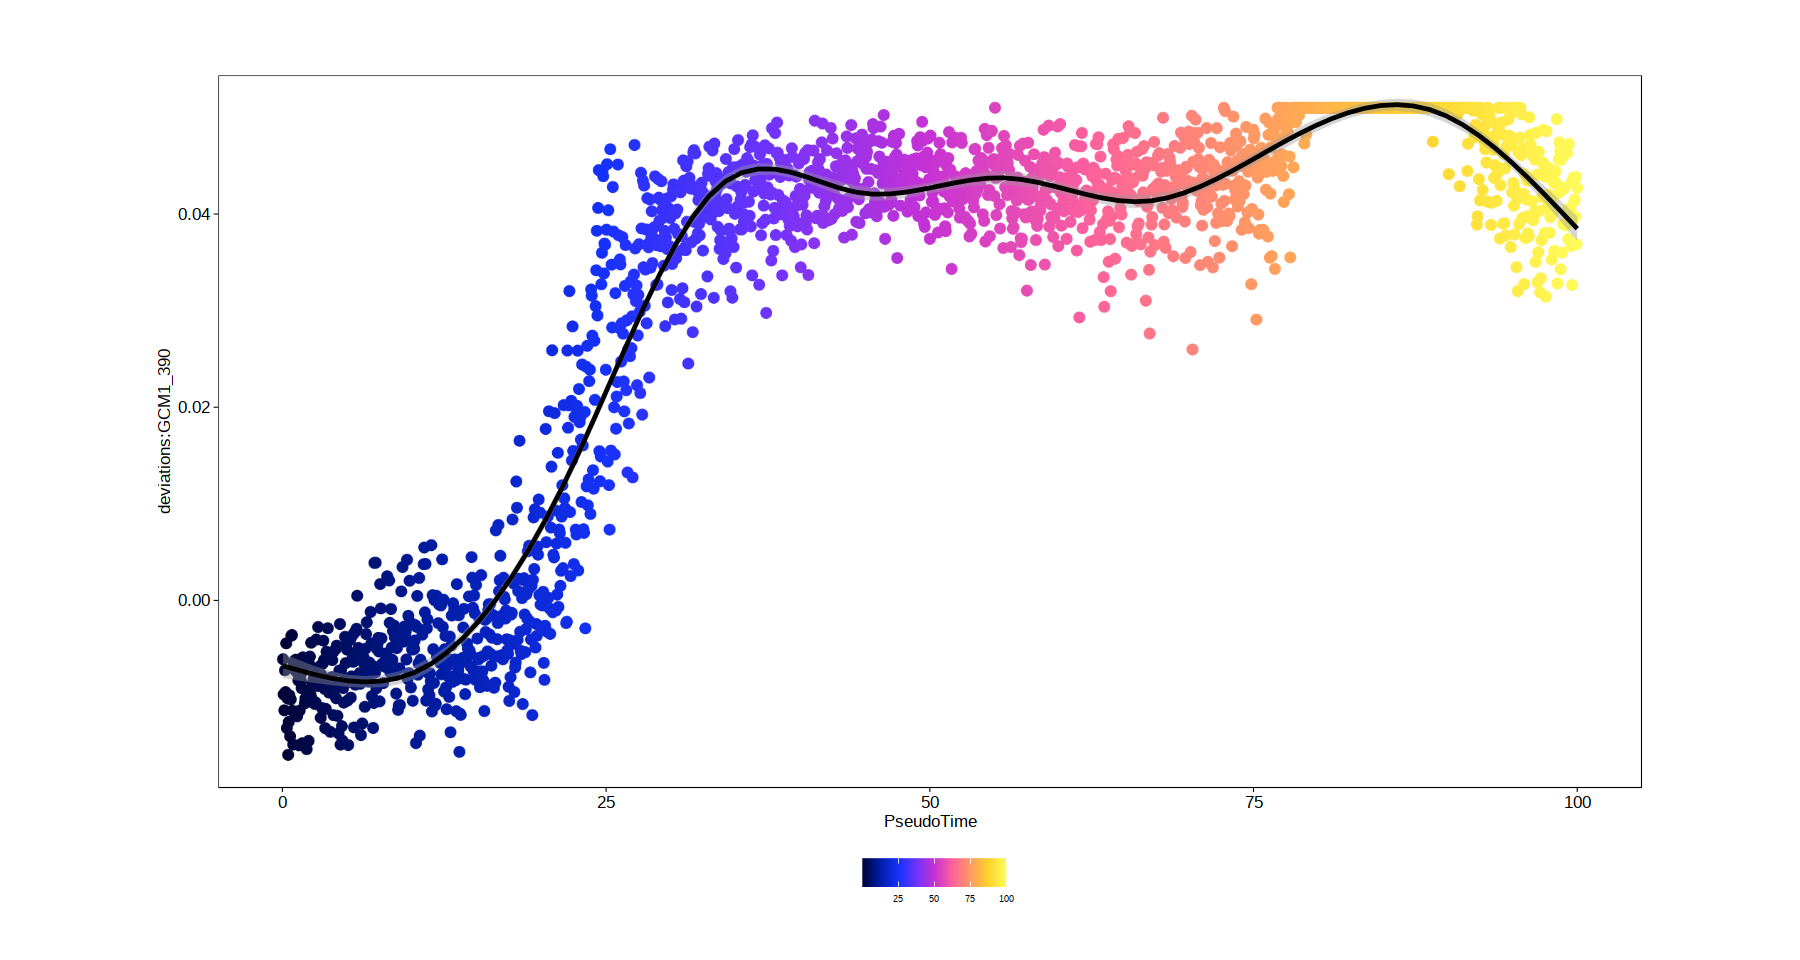

In [8]:
p = plotTrajectory(ArchRProject.filt, trajectory = "Tropho", colorBy = "MotifMatrix", name = 'deviations:GCM1_390', continuousSet = "horizonExtra")
p

In [48]:
trajMM  <- getTrajectory(ArchRProj = ArchRProject.filt, name = "Tropho", useMatrix = "MotifMatrix", log2Norm = FALSE)
names = sapply(strsplit(rownames(trajMM),":"), `[`, 2)
names = sapply(strsplit(names,"_"), `[`, 1)
rownames(trajMM) = names

Creating Trajectory Group Matrix..

Some values are below 0, this could be a DeviationsMatrix in which scaleTo should be set = NULL.
Continuing without depth normalization!

Smoothing...



In [49]:
p1 = plotTrajectoryHeatmap(trajMM, pal = paletteContinuous(set = "solarExtra"), labelTop  = 100)

ArchR logging to : ArchRLogs/ArchR-plotTrajectoryHeatmap-17e71476c99d7-Date-2022-01-05_Time-14-18-59.log
If there is an issue, please report to github with logFile!

useSeqnames is NULL or greater than 1 with a Sparse.Assays.Matrix trajectory input.

2022-01-05 14:18:59 : 

force=FALSE thus continuing with subsetting useSeqnames = z

2022-01-05 14:18:59 : 

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectoryHeatmap-17e71476c99d7-Date-2022-01-05_Time-14-18-59.log



In [ ]:
# Export TF names in heatmap to select ones of interest
write.csv(rownames(p1@ht_list$MotifMatrix@matrix),file.path(io$plot.trophoblast, 'heatmap_motifs.csv'), row.names=FALSE)

In [52]:
motifs_to_keep = c('GATA3',
                   'TFAP2B',
                   'ID1',
                   'ELF3', 
                   'ETV7',
                   'RREB',
                   'VENTX',
                   'TWIST1', 
                   'TFEC'
                   
                  )
keep = grep(paste(motifs_to_keep, collapse='|'), rownames(trajMM), value = TRUE)

keep_rows = data.table('TF' = rownames(p1@ht_list$MotifMatrix@matrix), 'row' = 1:length(rownames(p1@ht_list$MotifMatrix@matrix))) %>%
    .[TF %in% keep,] %>% .$row

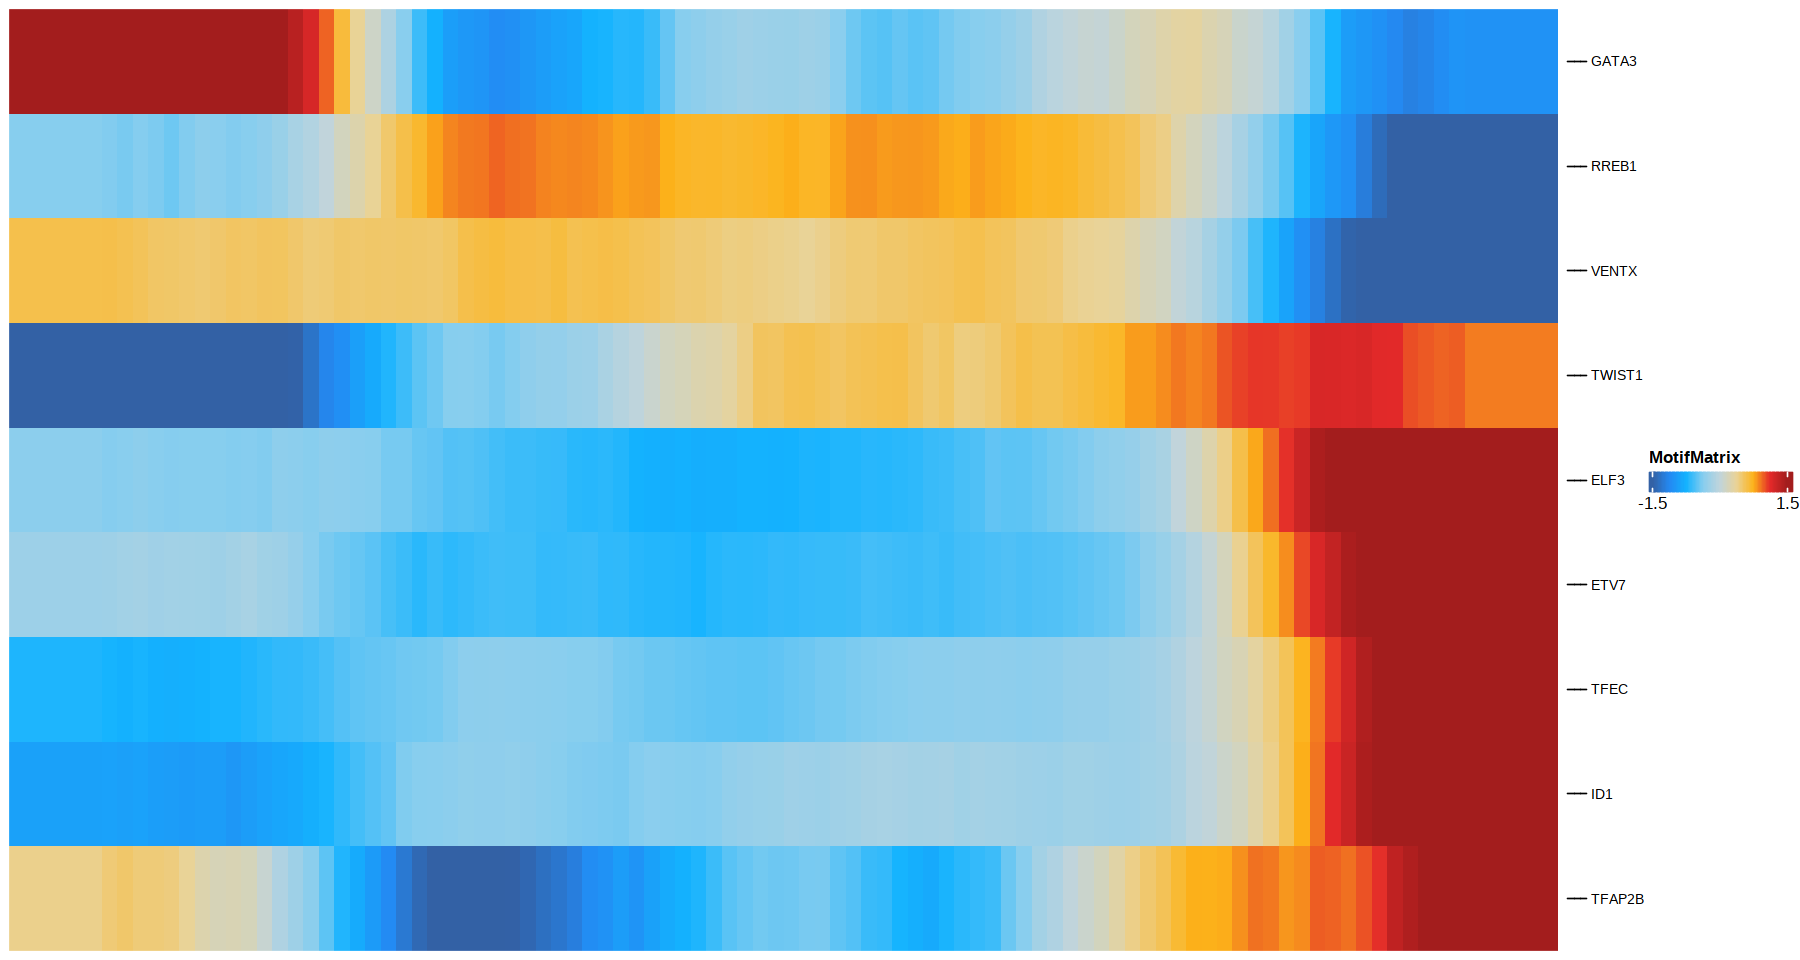

In [53]:
p1[keep_rows]

In [101]:
trajGSM <- getTrajectory(ArchRProj = ArchRProject.filt, name = "Tropho", useMatrix = "GeneScoreMatrix", log2Norm = TRUE)

Creating Trajectory Group Matrix..

Smoothing...



In [102]:
p2 <- trajectoryHeatmap(trajGSM,  pal = paletteContinuous(set = "horizonExtra"))

ArchR logging to : ArchRLogs/ArchR-plotTrajectoryHeatmap-2dc6d1b783a88-Date-2021-12-15_Time-15-51-09.log
If there is an issue, please report to github with logFile!

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectoryHeatmap-2dc6d1b783a88-Date-2021-12-15_Time-15-51-09.log



In [103]:
trajGIM <- getTrajectory(ArchRProj = ArchRProject.filt, name = "Tropho", useMatrix = "GeneIntegrationMatrix", log2Norm = FALSE)

Creating Trajectory Group Matrix..

Smoothing...



In [104]:
p3 <- plotTrajectoryHeatmap(trajGIM,  pal = paletteContinuous(set = "blueYellow"))

ArchR logging to : ArchRLogs/ArchR-plotTrajectoryHeatmap-2dc6d686ccb59-Date-2021-12-15_Time-15-51-39.log
If there is an issue, please report to github with logFile!

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectoryHeatmap-2dc6d686ccb59-Date-2021-12-15_Time-15-51-39.log



In [105]:
trajPM  <- getTrajectory(ArchRProj = ArchRProject.filt, name = "Tropho", useMatrix = "PeakMatrix", log2Norm = TRUE)

Creating Trajectory Group Matrix..

Smoothing...



In [106]:
p4 <- plotTrajectoryHeatmap(trajPM, pal = paletteContinuous(set = "solarExtra"))

ArchR logging to : ArchRLogs/ArchR-plotTrajectoryHeatmap-2dc6d4099692-Date-2021-12-15_Time-15-53-05.log
If there is an issue, please report to github with logFile!

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectoryHeatmap-2dc6d4099692-Date-2021-12-15_Time-15-53-05.log



In [109]:
plotPDF(p1, p2, p3, p4, name = "Plot-Tropho-Traj-Heatmaps.pdf", ArchRProj = ArchRProject.filt, addDOC = FALSE, width = 6, height = 8)

Plotting ComplexHeatmap!

Plotting ComplexHeatmap!

Plotting ComplexHeatmap!

Plotting ComplexHeatmap!



In [48]:
test = getCellNames(ArchRProject.filt)

In [49]:
head(test)

[1] "rabbit_BGRGP1#AAACGAAAGCCCATGC-1" "rabbit_BGRGP1#AAACGAAAGTACCTCA-1"
[3] "rabbit_BGRGP1#AAACGAAAGTTTGGAA-1" "rabbit_BGRGP1#AAACGAACAAATAGTG-1"
[5] "rabbit_BGRGP1#AAACGAACAAGAGCGT-1" "rabbit_BGRGP1#AAACGAACACCTCGTT-1"

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-2dc6d2ef2a6a1-Date-2021-12-15_Time-15-18-30.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = MotifMatrix

Getting Matrix Values...

2021-12-15 15:18:30 : 

1 
2 
3 
4 
5 
6 
7 
8 


Imputing Matrix

Using weights on disk

1 of 7

2 of 7

3 of 7

4 of 7

5 of 7

6 of 7

7 of 7

Using weights on disk

1 of 7

2 of 7

3 of 7

4 of 7

5 of 7

6 of 7

7 of 7

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-2dc6d2ef2a6a1-Date-2021-12-15_Time-15-18-30.log



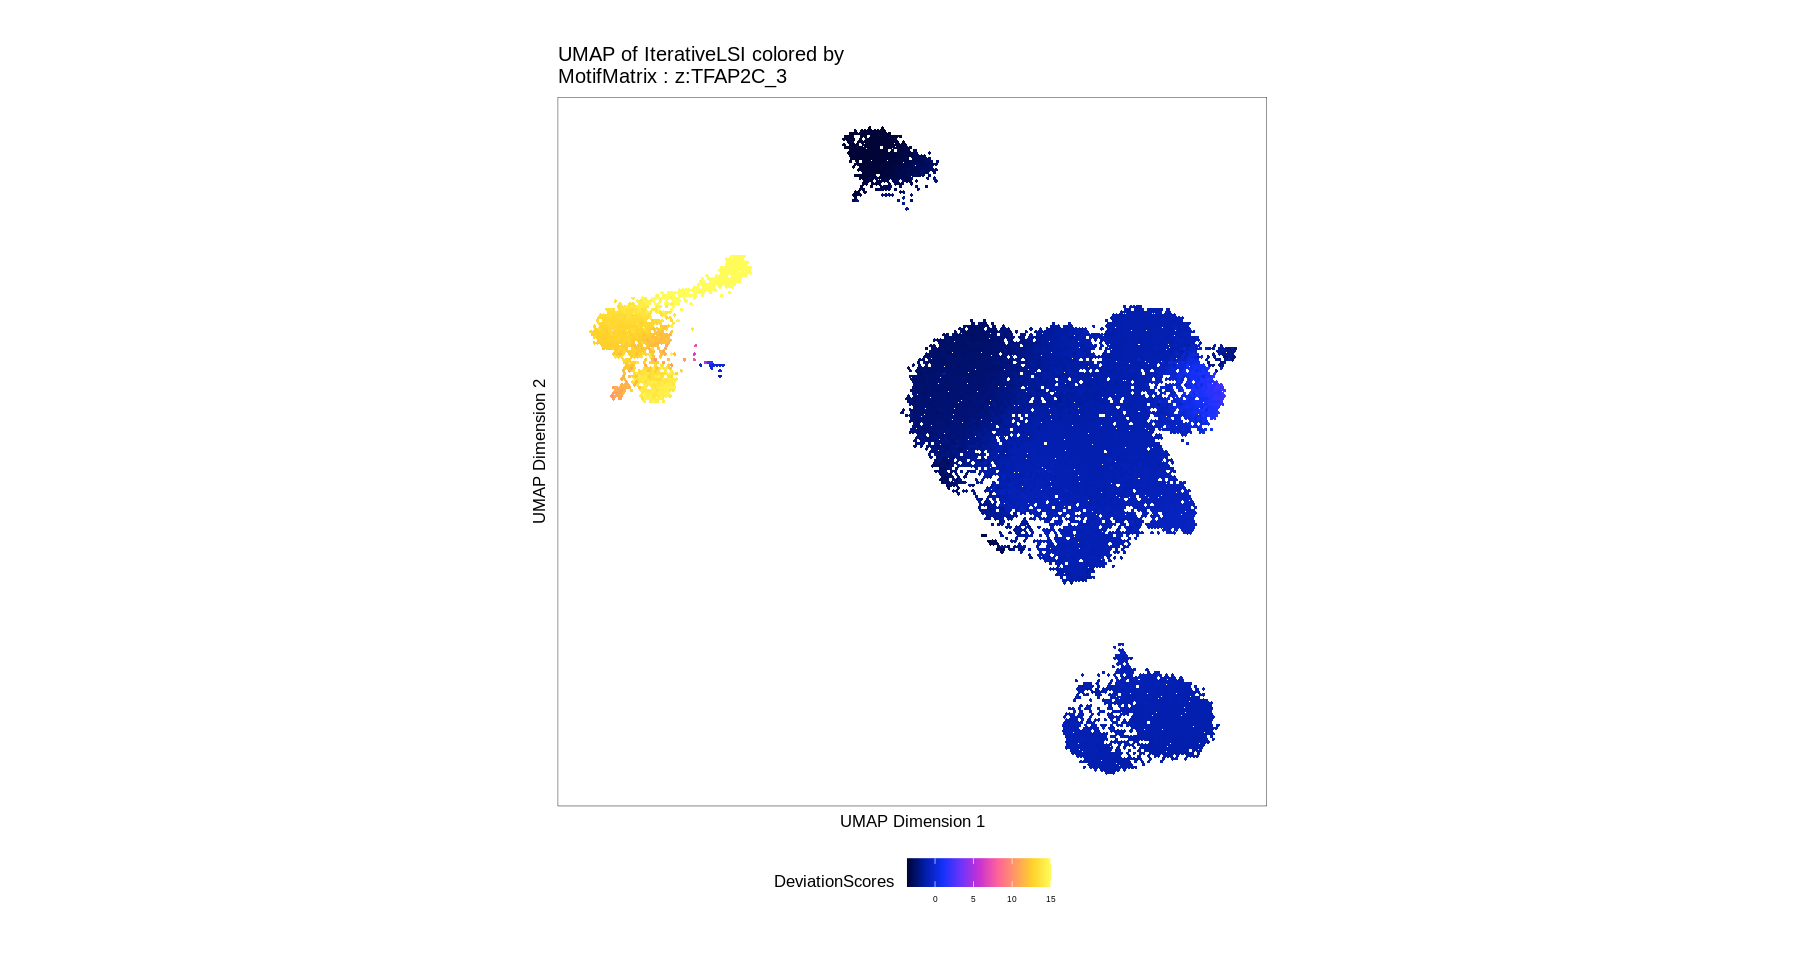

In [47]:
plotEmbedding(ArchRProject.filt, colorBy = "MotifMatrix", name = 'z:TFAP2C_3', continuousSet = "horizonExtra")

In [87]:
### ArchR's plotting function doesn't look nice for these trajectories ###

In [186]:
umap = getEmbedding(ArchRProject.filt)
colnames(umap) = c('umap1', 'umap2')
umap = as.data.frame(merge(umap, ArchRProject.filt@cellColData, by=0))

png 
  2

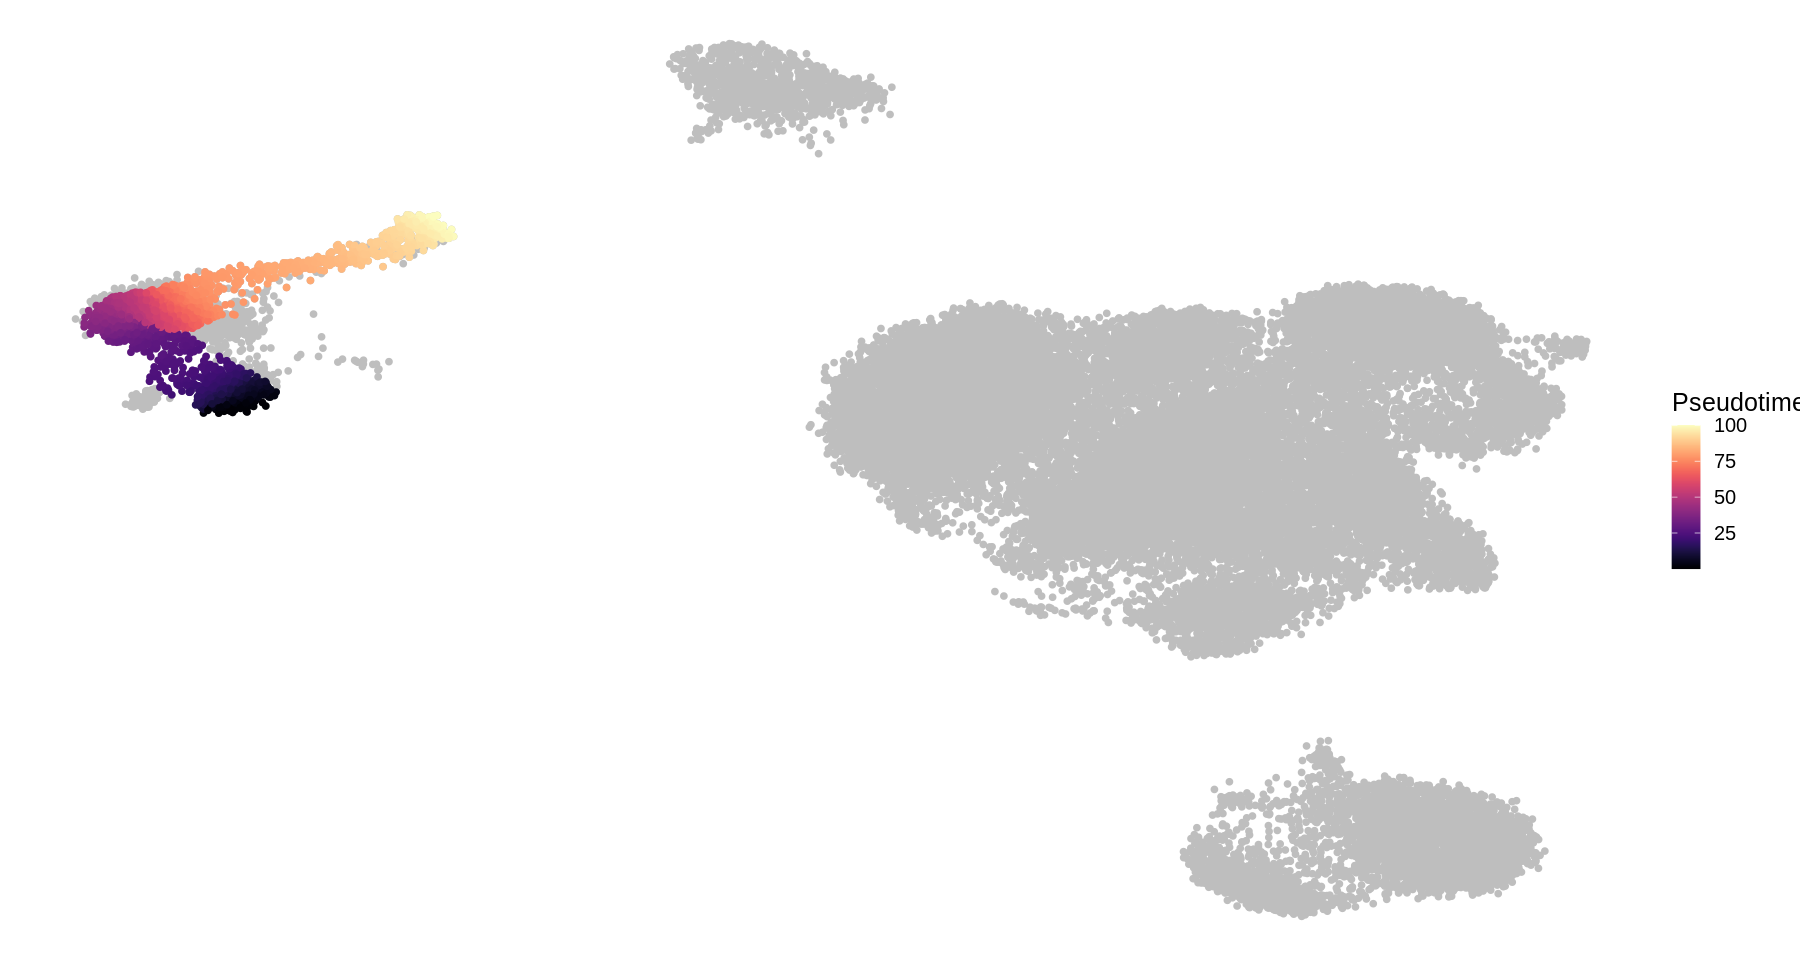

In [209]:
p = ggplot(umap, aes(umap1, umap2)) + 
    geom_point(col='grey') + 
    geom_point(data=umap[!is.na(umap$Tropho),], aes(umap1, umap2, col=Tropho)) + 
    scale_color_viridis(option='magma', name='Pseudotime') + 
    theme_void() + theme(text=element_text(size=15))

p
pdf(file = file.path(io$plot.trophoblast, 'Trophoblast_pseudotime.pdf'), width = 10, height = 10) 
    p 
dev.off()

In [90]:
getAvailableMatrices(ArchRProject.filt)

[1] "GeneIntegrationMatrix" "GeneScoreMatrix"       "MotifMatrix"          
[4] "PeakMatrix"            "TileMatrix"

In [192]:
# Get gene score matrix
GeneScore = getMatrixFromProject(
  ArchRProj = ArchRProject.filt,
  useMatrix = "GeneScoreMatrix")

# Rename columns & rows
gene_names = GeneScore@elementMetadata$name
GeneScore = GeneScore@assays@data$GeneScoreMatrix
rownames(GeneScore) = gene_names

# Get GeneIntegrationMatrix matrix
GeneIntegration = getMatrixFromProject(
  ArchRProj = ArchRProject.filt,
  useMatrix = "GeneIntegrationMatrix")

# Rename columns & rows
gene_names = GeneIntegration@elementMetadata$name
GeneIntegration = GeneIntegration@assays@data$GeneIntegration
rownames(GeneIntegration) = gene_names

# Get gene score matrix
Motif = getMatrixFromProject(
  ArchRProj = ArchRProject.filt,
  useMatrix = "MotifMatrix")

# Rename columns & rows
gene_names = sapply(strsplit(Motif@elementMetadata$name,"_"), `[`, 1)
Motif = Motif@assays@data$z
rownames(Motif) = gene_names

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-2dc6d1513d416-Date-2021-12-15_Time-16-56-01.log
If there is an issue, please report to github with logFile!

2021-12-15 16:58:11 : Organizing colData, 2.169 mins elapsed.

2021-12-15 16:58:11 : Organizing rowData, 2.171 mins elapsed.

2021-12-15 16:58:11 : Organizing rowRanges, 2.171 mins elapsed.

2021-12-15 16:58:11 : Organizing Assays (1 of 1), 2.172 mins elapsed.

2021-12-15 16:58:35 : Constructing SummarizedExperiment, 2.558 mins elapsed.

2021-12-15 16:58:36 : Finished Matrix Creation, 2.579 mins elapsed.

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-2dc6d2795aaaf-Date-2021-12-15_Time-16-58-36.log
If there is an issue, please report to github with logFile!

2021-12-15 17:00:00 : Organizing colData, 1.406 mins elapsed.

2021-12-15 17:00:01 : Organizing rowData, 1.412 mins elapsed.

2021-12-15 17:00:01 : Organizing rowRanges, 1.412 mins elapsed.

2021-12-15 17:00:01 : Organizing Assays (1 of 1), 1.412 mins elapsed.


In [131]:
gene_map = read.csv(file.path(io$basedir, 'gene_map.csv'))

In [193]:
gene_map = read.csv(file.path(io$basedir, 'gene_map_biomart.csv'))
colnames(gene_map) = c('gene_id', 'symbol')

plot_traj = function(gene){
    umap = getEmbedding(ArchRProject.filt)
    colnames(umap) = c('umap1', 'umap2')
    umap = as.data.frame(merge(umap, ArchRProject.filt@cellColData, by=0))
    id = gene_map[gene_map$symbol== gene,]$gene_id
    message(gene)
    
    # gene score
    imputed_genescore = suppressMessages(imputeMatrix(mat = t(as.matrix(GeneScore[id,])), 
                                     imputeWeights = getImputeWeights(ArchRProject.filt)))
    imputed_genescore = as.data.frame(imputed_genescore) 
    
    colnames(imputed_genescore) = 'genescore'
    
    umap = merge(umap, imputed_genescore, by.x='Row.names', by.y=0)
    
    p11 = ggplot(umap, aes(umap1, umap2)) + 
        geom_point(col='grey') + 
        geom_point(data=umap[!is.na(umap$Tropho),], aes(umap1, umap2, col=genescore)) + 
        scale_color_viridis(option='magma', name='GeneScore') + 
        ggtitle(gene) + 
        theme_void() + 
        theme(text=element_text(size=10), 
              plot.title = element_text(size=22))
    
    p12 = ggplot(umap[!is.na(umap$Tropho),], aes(Tropho,genescore, col= genescore)) + 
        geom_point() + 
        scale_color_viridis(option='magma', name='GeneScore') +
        geom_smooth(col='black') + 
        xlab('Pseudotime') + ylab('Gene Score') + 
        theme_classic() + 
        theme(text = element_text(size = 15), 
              legend.title=element_text(size=10))
    
    # gene integration
    imputed_geneintegration = suppressMessages(imputeMatrix(mat = t(as.matrix(GeneIntegration[id,])), 
                                     imputeWeights = getImputeWeights(ArchRProject.filt)))
    
    imputed_geneintegration = as.data.frame(imputed_geneintegration) 
    colnames(imputed_geneintegration) = 'geneintegration'
    
    umap = merge(umap, imputed_geneintegration, by.x='Row.names', by.y=0)
    
    p21 = ggplot(umap, aes(umap1, umap2)) + 
        geom_point(col='grey') + 
        geom_point(data=umap[!is.na(umap$Tropho),], aes(umap1, umap2, col=geneintegration))  + 
        scale_color_viridis(option='plasma', name='GeneIntegration') + 
        ggtitle('') + 
        theme_void() + 
        theme(text=element_text(size=10), 
              plot.title = element_text(size=22))
    
    p22 = ggplot(umap[!is.na(umap$Tropho),], aes(Tropho,geneintegration, col= geneintegration)) + 
        geom_point() + 
        scale_color_viridis(option='plasma', name='geneintegration') +
        geom_smooth(col='black') + 
        xlab('Pseudotime') + ylab('Gene Integration') + 
        theme_classic() + 
        theme(text = element_text(size = 15), 
              legend.title=element_text(size=10))
    
    # motifs
    if(gene %in% rownames(Motif)){
        imputed_motif = suppressMessages(imputeMatrix(mat = t(as.matrix(Motif[gene,])), 
                                         imputeWeights = getImputeWeights(ArchRProject.filt)))

        imputed_motif = as.data.frame(imputed_motif) 
        colnames(imputed_motif) = 'motif'

        umap = merge(umap, imputed_motif, by.x='Row.names', by.y=0)

        p31 = ggplot(umap, aes(umap1, umap2)) + 
            geom_point(col='grey') + 
            geom_point(data=umap[!is.na(umap$Tropho),], aes(umap1, umap2, col=motif)) + 
            scale_color_viridis(option='viridis', name='MotifAccessibility') + 
            ggtitle('') + 
            theme_void() +
            theme(text=element_text(size=10), 
                  plot.title = element_text(size=22))

        p32 = ggplot(umap[!is.na(umap$Tropho),], aes(Tropho,motif, col= motif)) + 
            geom_point() + 
            scale_color_viridis(option='viridis', name='motif') +
            geom_smooth(col='black') + 
            xlab('Pseudotime') + ylab('Motif Accessibility') + 
            theme_classic() + 
            theme(text = element_text(size = 15), 
                  legend.title=element_text(size=10))
    
    grid.arrange(p11,p21,p31, p12, p22, p32, ncol=3)

    }else{
        grid.arrange(p11,p21,p12, p22, ncol=2)
    }

}

In [213]:
gene_map[gene_map$gene_id=='ENSOCUG00000029640',]$symbol = 'ORY1'
genes = c(
#         'VTCN1',
#        'GCM1',
#         'PDE6H',# from https://academic.oup.com/endo/article/150/2/1000/2455727
#         'S100A4',
#         'TNNI2',
#         'COL11A1',
#         'ADAM12',
#         'FABP7',
#         'SPON2',    '      
#         'ND2',# Trophoblast markers atlas
#         'COX2',
#         'CDK2', 
#         'ATP6V0E1', 
#         'RPN1', 
#         'SOD1', 
#        'GATA3',
#         'HSPD1', 
    #        'FABP3',
#         'NME2',
#          'ORY1',
    #'SYN1', 'SYN2'
   # 'TEAD1','CDX4','CDX1', 'TEAD3', 'RREB1', 'ELF5', 'MITF', 'USF1', 'ID2', 'ID1', 'TFAP2C', 'TFAP2B' #heatmap
    'CEPBA'
         ) 

# select only genes present in data
genes = gene_map[gene_map$gene_id %in% rownames(GeneScore)[rownames(GeneScore) %in% gene_map[gene_map$symbol %in% genes,]$gene_id],]$symbol

In [214]:
genes

character(0)

In [212]:
for(i in genes){
    pdf(file = file.path(io$plot.trophoblast, paste0(i,'_trophoblast.pdf')), width = 15, height = 8) 
        plot_traj(i)
    dev.off()
}

GCM1

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



In [230]:
gene_map = read.csv(file.path(io$basedir, 'gene_map_biomart.csv'))
colnames(gene_map) = c('gene_id', 'symbol')

plot_all = function(gene){
    umap = getEmbedding(ArchRProject.filt)
    colnames(umap) = c('umap1', 'umap2')
    umap = as.data.frame(merge(umap, ArchRProject.filt@cellColData, by=0))
    id = gene_map[gene_map$symbol== gene,]$gene_id
    message(gene)
    
    # gene score
    imputed_genescore = suppressMessages(imputeMatrix(mat = t(as.matrix(GeneScore[id,])), 
                                     imputeWeights = getImputeWeights(ArchRProject.filt)))
    imputed_genescore = as.data.frame(imputed_genescore) 
    
    colnames(imputed_genescore) = 'genescore'
    
    umap = merge(umap, imputed_genescore, by.x='Row.names', by.y=0)
    
    p11 = ggplot(umap, aes(umap1, umap2, col=genescore)) + 
        geom_point()  + 
        scale_color_viridis(option='magma', name='GeneScore') + 
        ggtitle(gene) + 
        theme_void() + 
        theme(text=element_text(size=10), 
              plot.title = element_text(size=22))
    
    # gene integration
    imputed_geneintegration = suppressMessages(imputeMatrix(mat = t(as.matrix(GeneIntegration[id,])), 
                                     imputeWeights = getImputeWeights(ArchRProject.filt)))
    
    imputed_geneintegration = as.data.frame(imputed_geneintegration) 
    colnames(imputed_geneintegration) = 'geneintegration'
    
    umap = merge(umap, imputed_geneintegration, by.x='Row.names', by.y=0)
    
    p21 = ggplot(umap, aes(umap1, umap2, col=geneintegration)) + 
        geom_point() + 
        scale_color_viridis(option='plasma', name='GeneIntegration') + 
        ggtitle('') + 
        theme_void() + 
        theme(text=element_text(size=10), 
              plot.title = element_text(size=22))
    
    # motifs
    if(gene %in% rownames(Motif)){
        imputed_motif = suppressMessages(imputeMatrix(mat = t(as.matrix(Motif[gene,])), 
                                         imputeWeights = getImputeWeights(ArchRProject.filt)))

        imputed_motif = as.data.frame(imputed_motif) 
        colnames(imputed_motif) = 'motif'

        umap = merge(umap, imputed_motif, by.x='Row.names', by.y=0)

        p31 = ggplot(umap, aes(umap1, umap2, col=motif)) + 
            geom_point() +  
            scale_color_viridis(option='viridis', name='MotifAccessibility') + 
            ggtitle('') + 
            theme_void() +
            theme(text=element_text(size=10), 
                  plot.title = element_text(size=22))
    
    grid.arrange(p11,p21,p31, ncol=3)

    }else{
        grid.arrange(p11,p21,ncol=2)
    }

}

CALCR



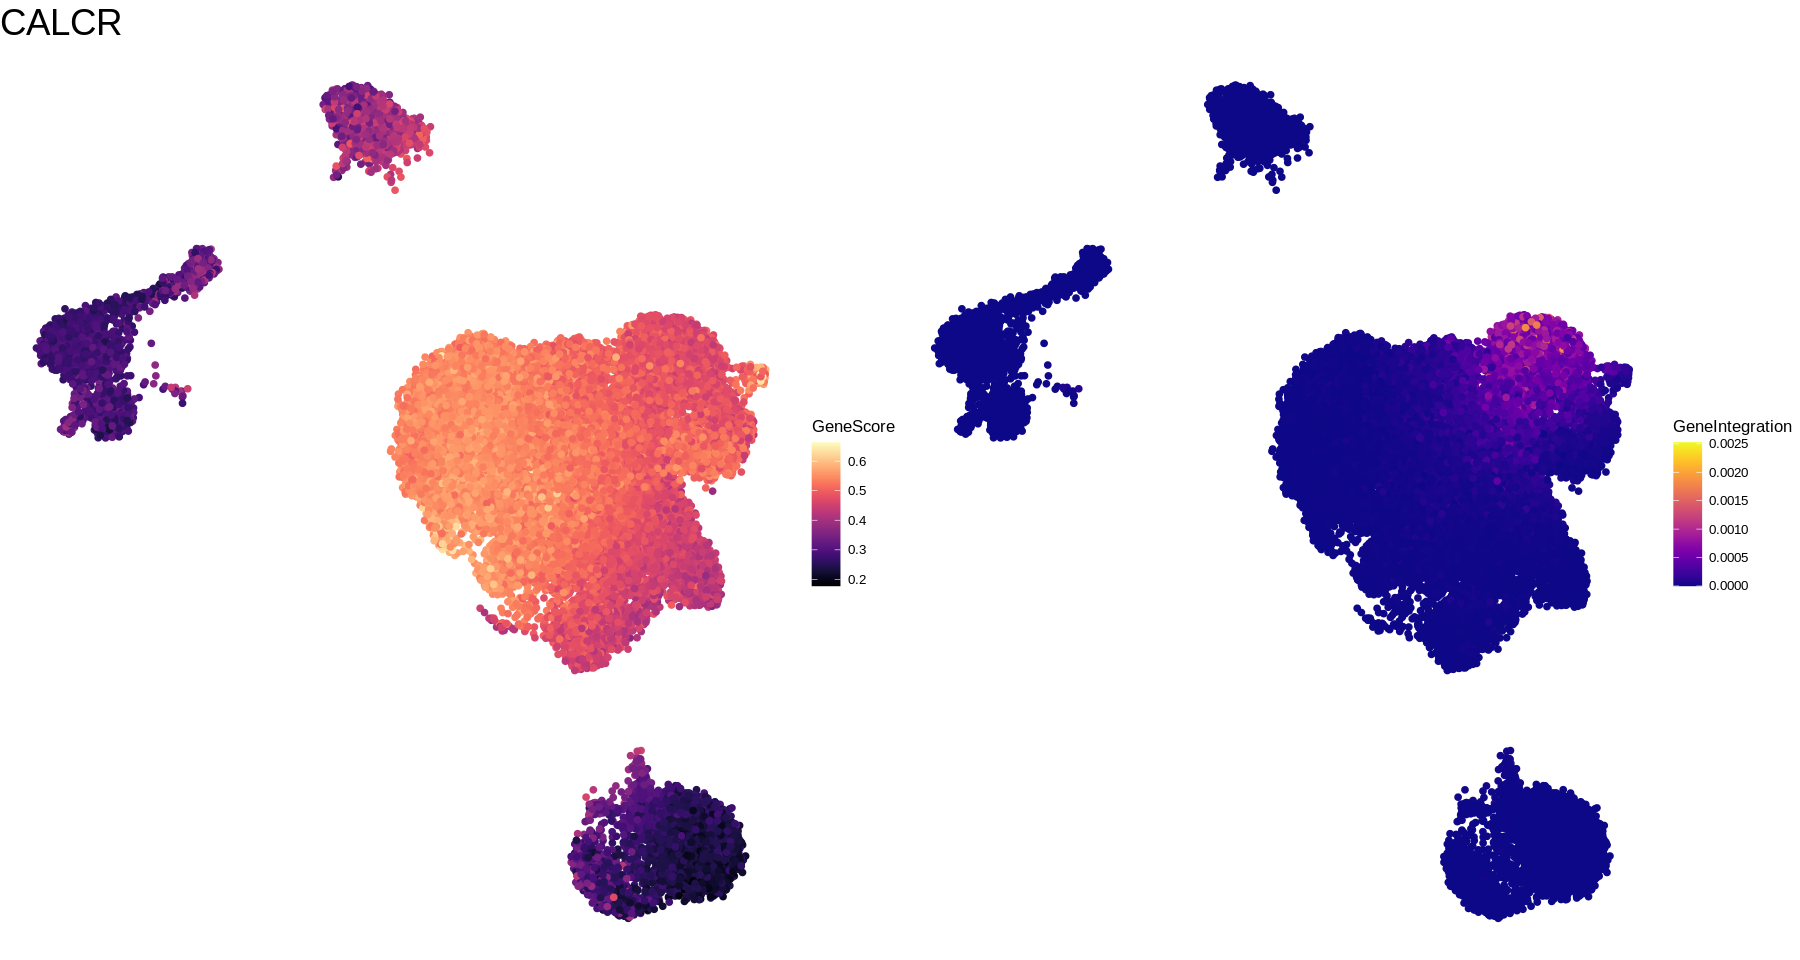

In [231]:
plot_all('CALCR')

CALCA



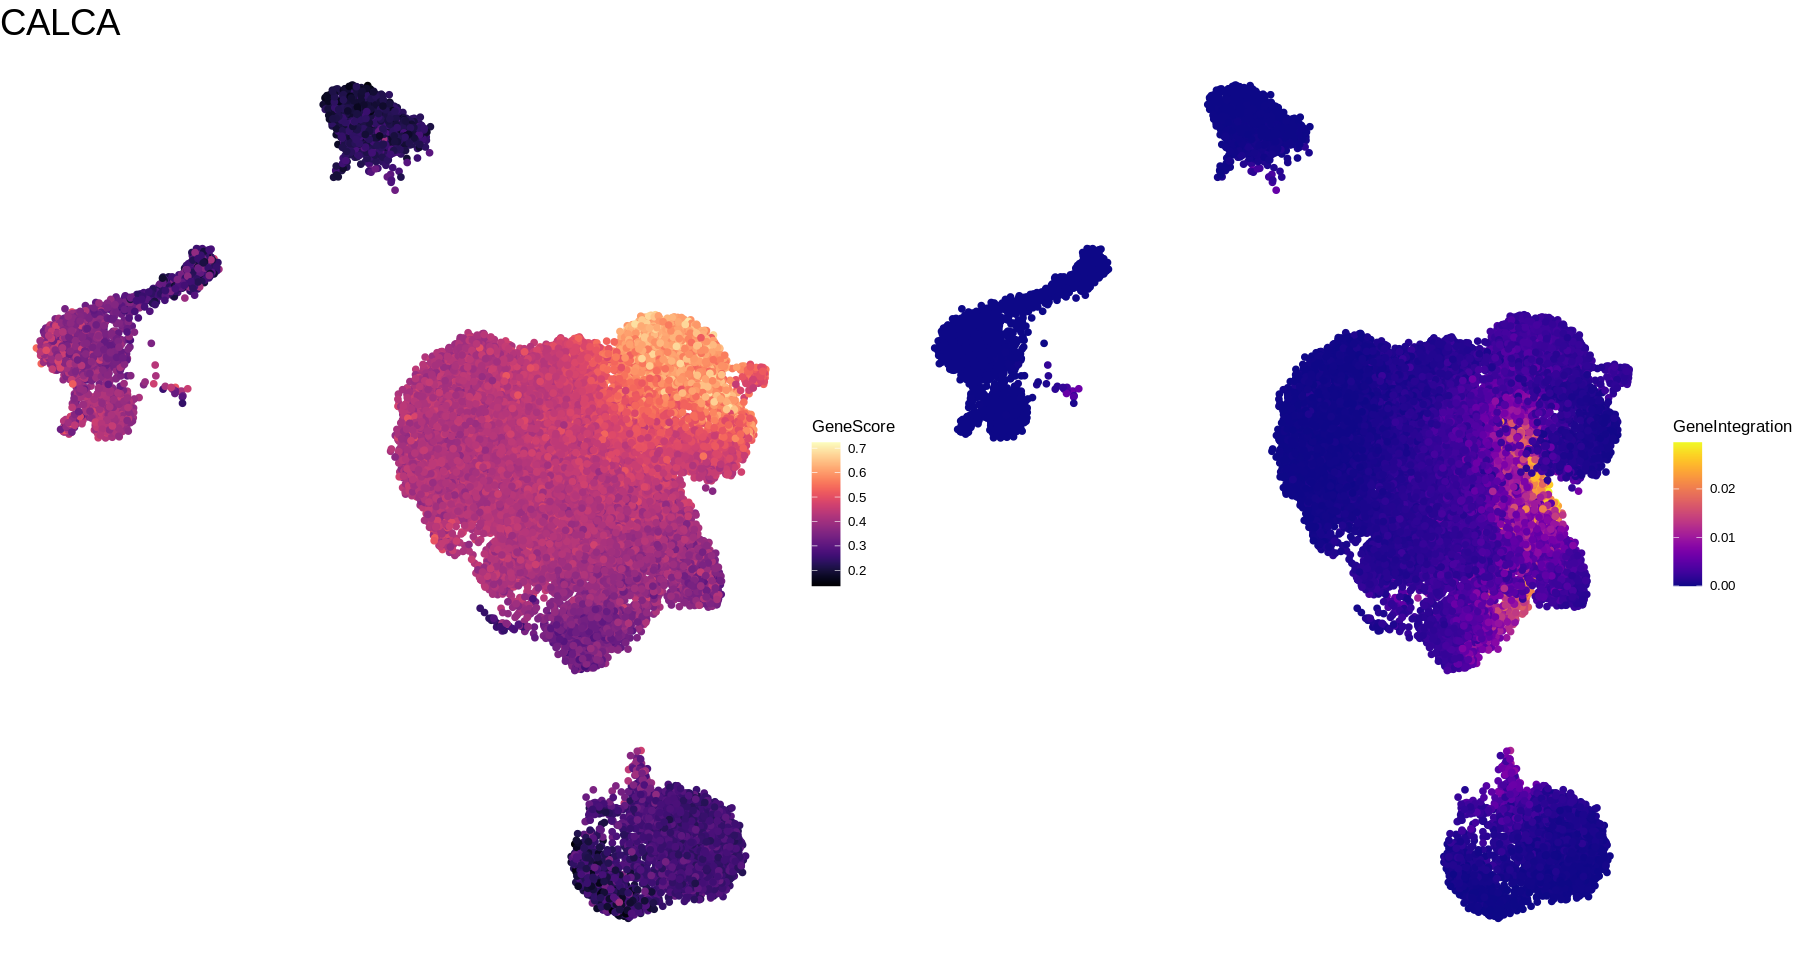

In [232]:
plot_all('CALCA')

# Endothelium reclustering

In [6]:
keep = rownames(ArchRProject.filt@cellColData[ArchRProject.filt@cellColData$celltype_manual=='Endothelium',])
endo = ArchRProject.filt[keep]

Dropping ImputeWeights Since You Are Subsetting Cells! ImputeWeights is a cell-x-cell Matrix!



In [64]:
unique(ArchRProject.filt@cellColData$predictedGroup_celltype)

[1] "Anterior Hypoblast"             "Primitive Streak"              
 [3] "Epiblast"                       "Trophoblast"                   
 [5] "Hypoblast"                      "Haematoendothelial progenitors"
 [7] "Visceral YS Endoderm"           "NMP"                           
 [9] "EXE mesoderm"                   "SCT"                           
[11] "CYT"                            "Cardiomyocytes"                
[13] "Posterior Mesoderm"             "Brain/Neural Tube"             
[15] "Anterior Mesoderm"              "Somitic Mesoderm"              
[17] "Early Amniotic Ectoderm"        "Endothelium"                   
[19] "Early Erythrocytes"             "Late Erythrocytes"             
[21] "Megakaryocytes"                 "Allantois"                     
[23] "YS Mesothelium"                 "Cranial Mesoderm"              
[25] "Neural Crest"                   "Placodes"                      
[27] "Chorion"

In [7]:
endo


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(25): Clusters sample ... ReadsInPeaks FRIP
numberOfCells(1): 849
medianTSS(1): 3.254
medianFrags(1): 31506

In [11]:
endo <- addIterativeLSI(
  ArchRProj = endo,
  useMatrix = 'TileMatrix', 
  name = "IterativeLSI", 
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = 2, 
  saveIterations = FALSE,
  varFeatures = 15000, 
  force = TRUE,
  dimsToUse = 1:10
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-8b012770732-Date-2021-12-16_Time-12-49-33.log
If there is an issue, please report to github with logFile!

2021-12-16 12:49:34 : Computing Total Across All Features, 0.017 mins elapsed.

2021-12-16 12:49:36 : Computing Top Features, 0.051 mins elapsed.

###########
2021-12-16 12:49:37 : Running LSI (1 of 2) on Top Features, 0.072 mins elapsed.
###########

2021-12-16 12:49:38 : Creating Partial Matrix, 0.072 mins elapsed.

2021-12-16 12:50:05 : Computing LSI, 0.528 mins elapsed.

2021-12-16 12:50:09 : Identifying Clusters, 0.601 mins elapsed.

2021-12-16 12:50:10 : Identified 6 Clusters, 0.618 mins elapsed.

2021-12-16 12:50:10 : Creating Cluster Matrix on the total Group Features, 0.619 mins elapsed.

2021-12-16 12:51:02 : Computing Variable Features, 1.477 mins elapsed.

###########
2021-12-16 12:51:02 : Running LSI (2 of 2) on Variable Features, 1.48 mins elapsed.
###########

2021-12-16 12:51:02 : Creating Parti

In [15]:
# Run UMAP
endo <- addUMAP(
  ArchRProj = endo, 
  #reducedDims = 'IterativeLSI_Harmony',
  reducedDims = 'IterativeLSI',
  name = "UMAP",
  metric = "cosine",
#  dimsToUse = 10,
  nNeighbors = 25, 
  minDist = 0.3, 
  seed = 42,
  saveModel = FALSE,
  force = TRUE
)

12:53:02 UMAP embedding parameters a = 0.9922 b = 1.112

12:53:02 Read 849 rows and found 10 numeric columns

12:53:02 Using Annoy for neighbor search, n_neighbors = 25

12:53:02 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:53:02 Writing NN index file to temp file /tmp/RtmpfBg2lq/file8b016529dc8

12:53:02 Searching Annoy index using 16 threads, search_k = 2500

12:53:02 Annoy recall = 100%

12:53:03 Commencing smooth kNN distance calibration using 16 threads

12:53:05 Initializing from normalized Laplacian + noise

12:53:05 Commencing optimization for 500 epochs, with 28000 positive edges

12:53:09 Optimization finished



ArchR logging to : ArchRLogs/ArchR-plotEmbedding-8b011046335-Date-2021-12-16_Time-12-54-38.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-8b011046335-Date-2021-12-16_Time-12-54-38.log



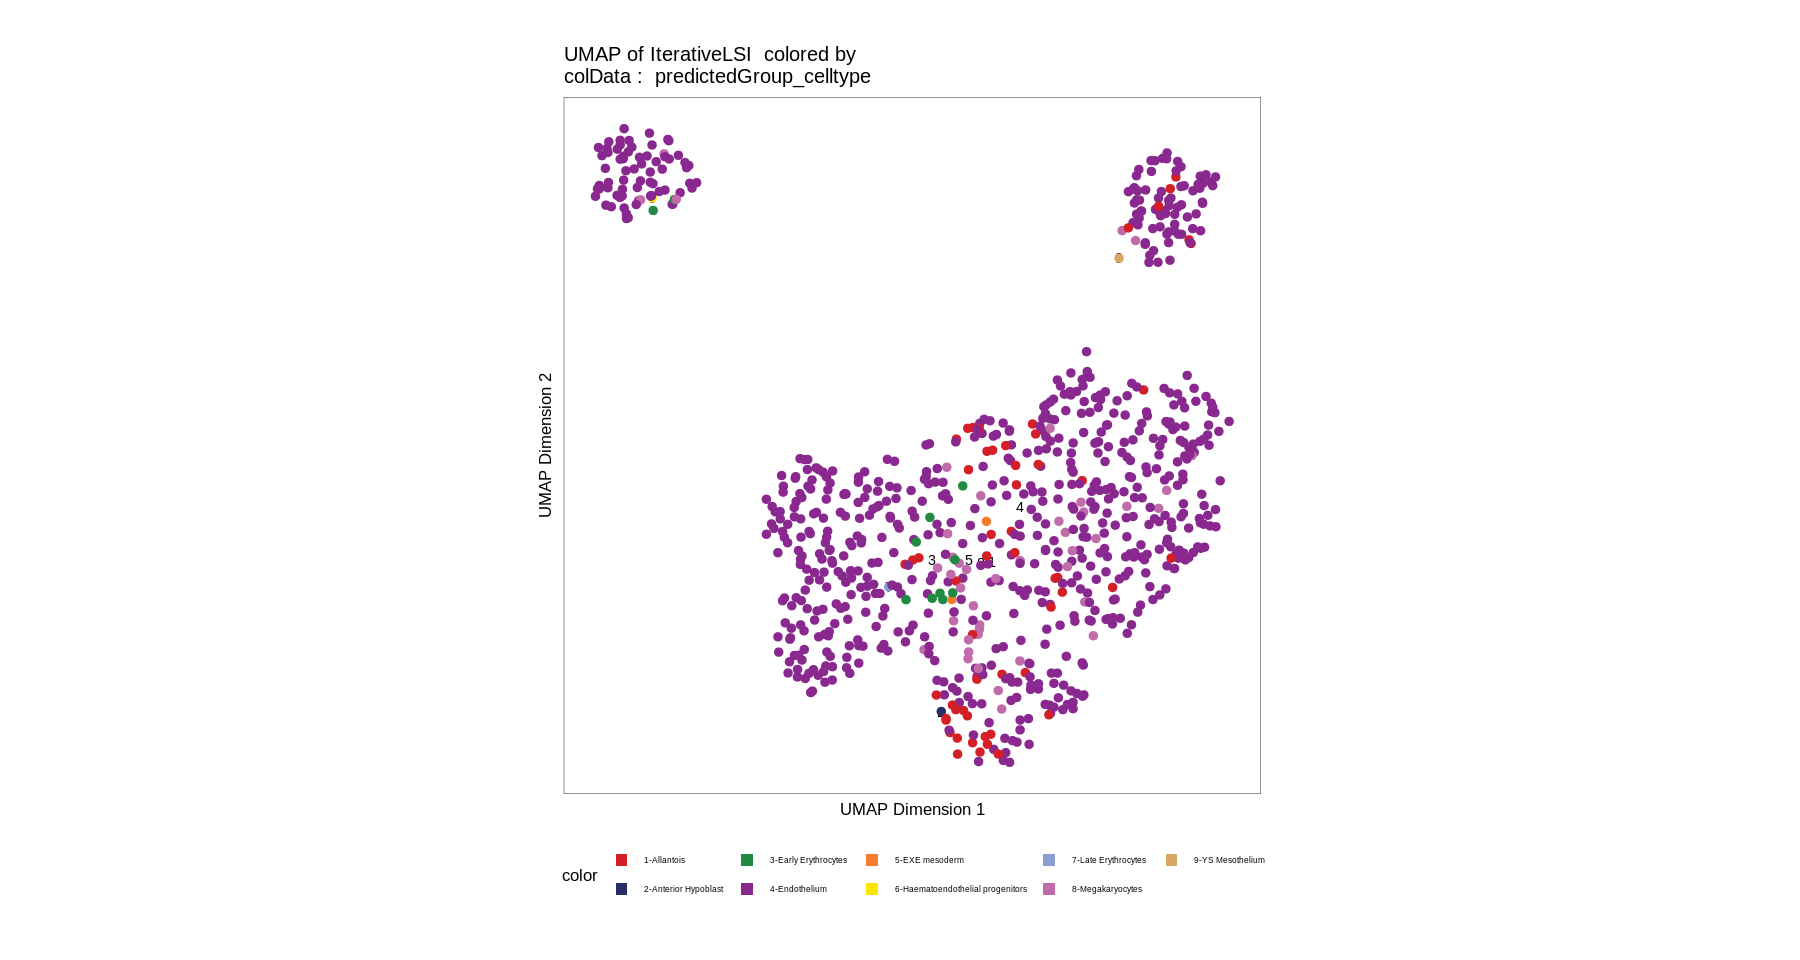

In [20]:
plotEmbedding(endo, colorBy = "cellColData", name = "predictedGroup_celltype") + geom_point(size = 2)

In [23]:
### Integrate with other RNA annotation
rna_in = '/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/RNA/'
sceRNA = readRDS(file.path(rna_in, 'RangedSummarizedExperiment.rds'))

In [24]:
rna_in_old = '/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC/RNA/'
alt_meta = read.csv(file.path(rna_in_old, 'metadata.csv'))

In [54]:
rownames(alt_meta) = alt_meta$cell

In [55]:
summary(alt_meta$cell == colnames(sceRNA))

   Mode 
logical 

In [56]:
colData = SummarizedExperiment(colData = alt_meta)
sceRNA@colData = colData@colData

In [57]:
celltypes = c('Allantois endothelium', 'Embryo proper endothelium', 'Venous endothelium','YS endothelium')
RNA_endo = sceRNA[,colData(sceRNA)$celltype %in% celltypes] # for RangedSummarizedExperiment object

In [58]:
    # Integrate
    endo <- addGeneIntegrationMatrix(
        ArchRProj = endo, 
        useMatrix = "GeneScoreMatrix",
        matrixName = "GeneIntegrationMatrix",
       # reducedDims = "IterativeLSI_Harmony",
        reducedDims = "IterativeLSI",
        seRNA = RNA_endo,
        addToArrow = FALSE,
        force= TRUE,
        groupRNA = "celltype",
        nameCell = "predictedCell_Un",
        nameGroup = "predictedGroup_celltype",
        nameScore = "predictedScore_celltype")

ArchR logging to : ArchRLogs/ArchR-addGeneIntegrationMatrix-8b0468451eb-Date-2021-12-16_Time-13-15-04.log
If there is an issue, please report to github with logFile!

2021-12-16 13:15:04 : Running Seurat's Integration Stuart* et al 2019, 0.004 mins elapsed.

2021-12-16 13:15:05 : Checking ATAC Input, 0.015 mins elapsed.

2021-12-16 13:15:05 : Checking RNA Input, 0.016 mins elapsed.

2021-12-16 13:15:08 : Found 20845 overlapping gene names from gene scores and rna matrix!, 0.071 mins elapsed.

2021-12-16 13:15:08 : Creating Integration Blocks, 0.071 mins elapsed.

2021-12-16 13:15:08 : Prepping Interation Data, 0.071 mins elapsed.

Filtering 20 dims correlated > 0.75 to log10(depth + 1)

2021-12-16 13:15:09 : Computing Integration in 1 Integration Blocks!, 0 mins elapsed.

2021-12-16 13:15:09 : Block (1 of 1) : Computing Integration, 0 mins elapsed.

2021-12-16 13:15:09 : Block (1 of 1) : Identifying Variable Genes, 0.006 mins elapsed.

2021-12-16 13:15:11 : Block (1 of 1) : Getting Gen

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-8b05ef53db-Date-2021-12-16_Time-13-22-07.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-8b05ef53db-Date-2021-12-16_Time-13-22-07.log



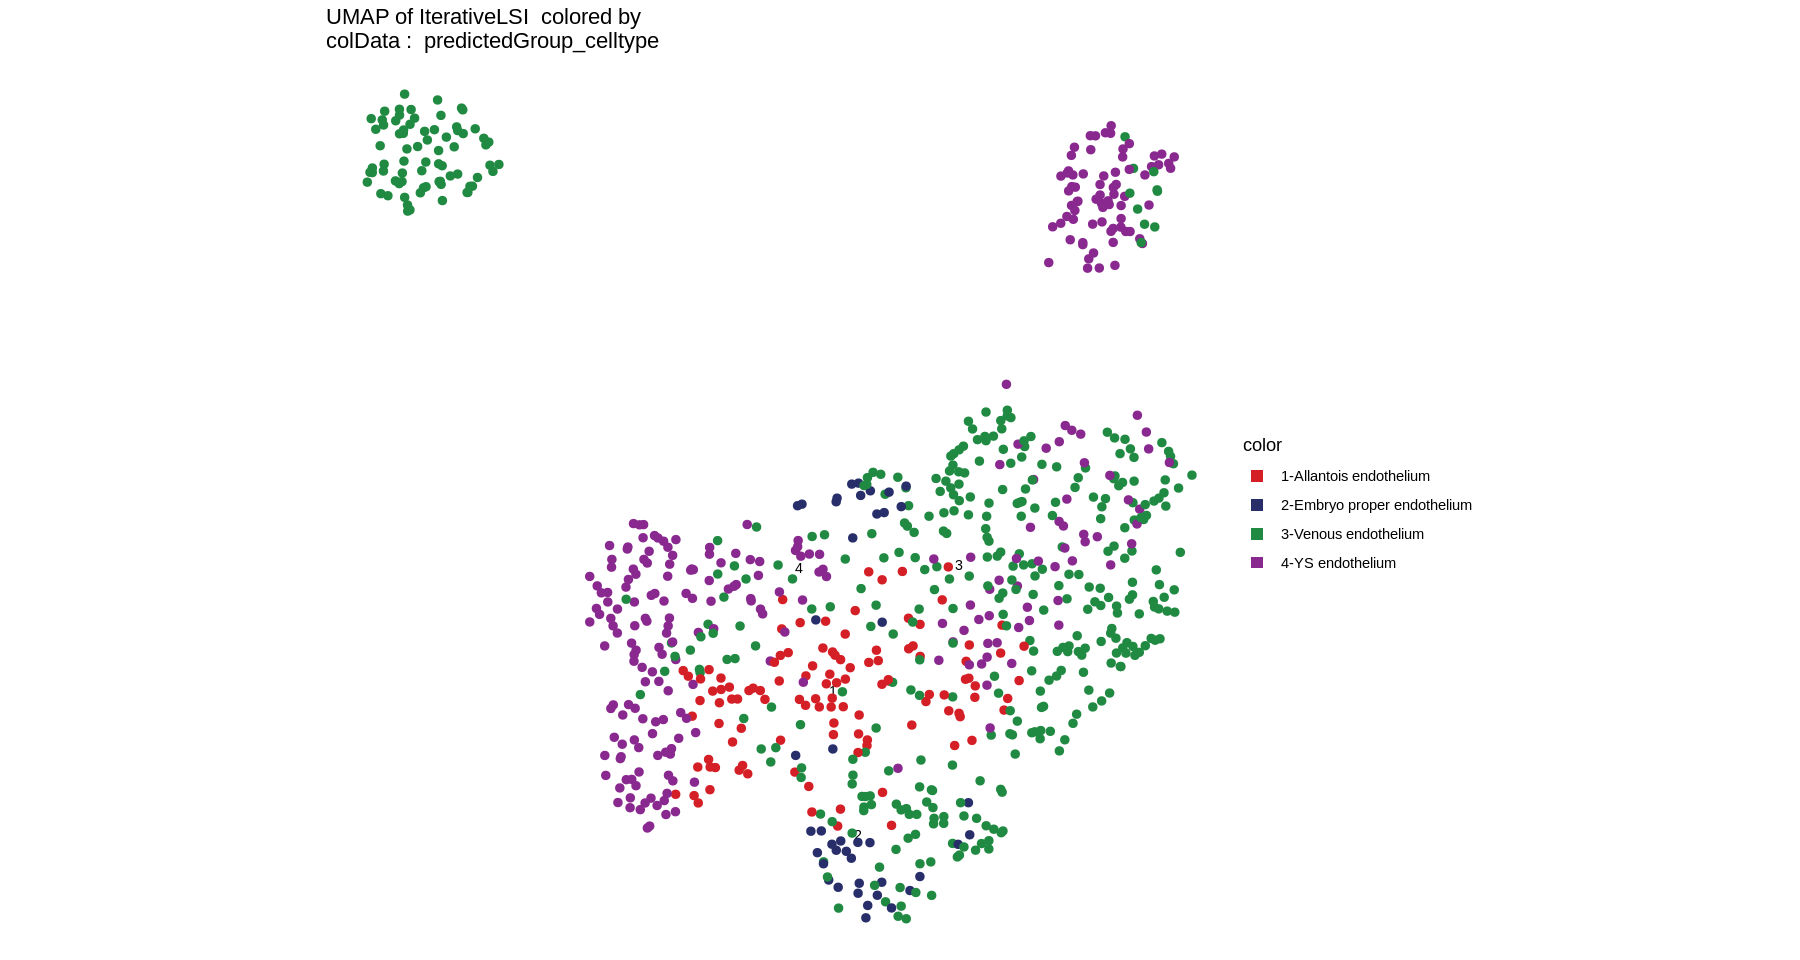

In [62]:
plotEmbedding(endo, colorBy = "cellColData", name = "predictedGroup_celltype") + geom_point(size = 2) + theme_void()

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-8b03c063e93-Date-2021-12-16_Time-13-25-14.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-8b03c063e93-Date-2021-12-16_Time-13-25-14.log



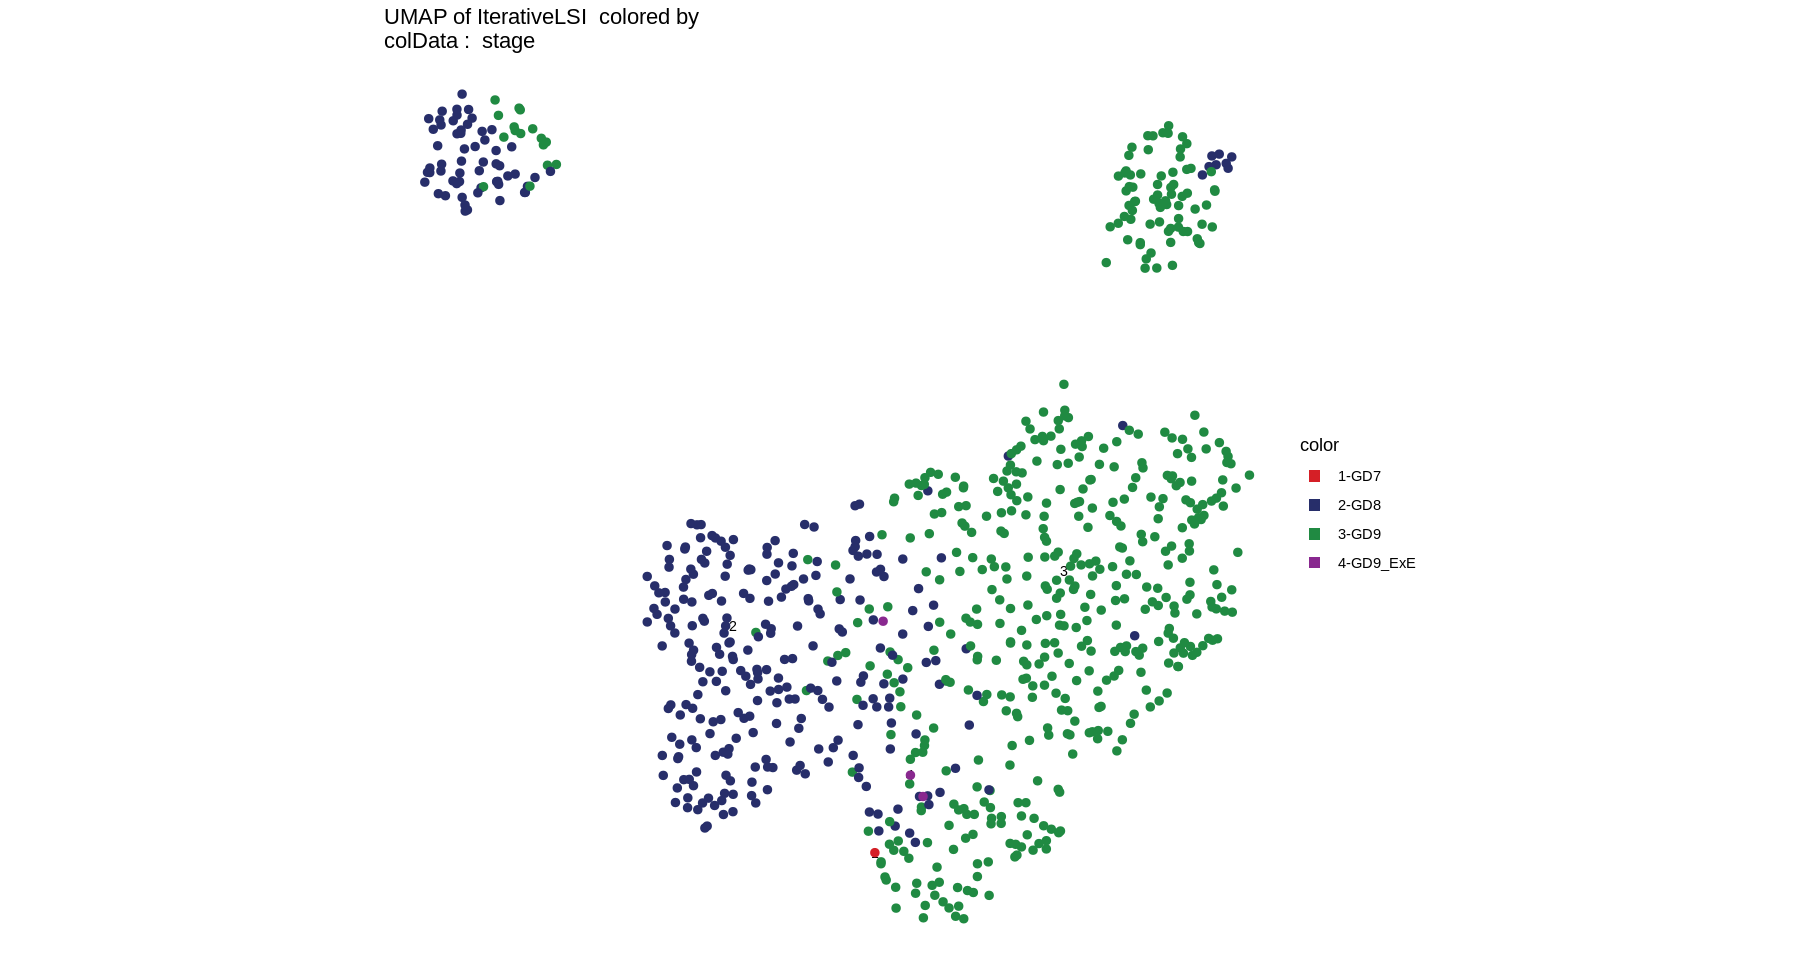

In [67]:
plotEmbedding(endo, colorBy = "cellColData", name = "stage") + geom_point(size = 2) + theme_void()

# rerun with other endothelial cells selected

In [69]:
keep = rownames(ArchRProject.filt@cellColData[ArchRProject.filt@cellColData$predictedGroup_celltype=='Endothelium',])
endo = ArchRProject.filt[keep]

Dropping ImputeWeights Since You Are Subsetting Cells! ImputeWeights is a cell-x-cell Matrix!



In [70]:
unique(ArchRProject.filt@cellColData$predictedGroup_celltype)

[1] "Anterior Hypoblast"             "Primitive Streak"              
 [3] "Epiblast"                       "Trophoblast"                   
 [5] "Hypoblast"                      "Haematoendothelial progenitors"
 [7] "Visceral YS Endoderm"           "NMP"                           
 [9] "EXE mesoderm"                   "SCT"                           
[11] "CYT"                            "Cardiomyocytes"                
[13] "Posterior Mesoderm"             "Brain/Neural Tube"             
[15] "Anterior Mesoderm"              "Somitic Mesoderm"              
[17] "Early Amniotic Ectoderm"        "Endothelium"                   
[19] "Early Erythrocytes"             "Late Erythrocytes"             
[21] "Megakaryocytes"                 "Allantois"                     
[23] "YS Mesothelium"                 "Cranial Mesoderm"              
[25] "Neural Crest"                   "Placodes"                      
[27] "Chorion"

In [71]:
endo


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(25): Clusters sample ... ReadsInPeaks FRIP
numberOfCells(1): 892
medianTSS(1): 3.2725
medianFrags(1): 29232

In [72]:
endo <- addIterativeLSI(
  ArchRProj = endo,
  useMatrix = 'TileMatrix', 
  name = "IterativeLSI", 
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = 2, 
  saveIterations = FALSE,
  varFeatures = 15000, 
  force = TRUE,
  dimsToUse = 1:10
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-8b02fc3d575-Date-2021-12-16_Time-13-28-13.log
If there is an issue, please report to github with logFile!

2021-12-16 13:28:19 : Computing Total Across All Features, 0.094 mins elapsed.

2021-12-16 13:28:22 : Computing Top Features, 0.142 mins elapsed.

###########
2021-12-16 13:28:23 : Running LSI (1 of 2) on Top Features, 0.17 mins elapsed.
###########

2021-12-16 13:28:23 : Creating Partial Matrix, 0.17 mins elapsed.

2021-12-16 13:28:47 : Computing LSI, 0.556 mins elapsed.

2021-12-16 13:28:52 : Identifying Clusters, 0.644 mins elapsed.

2021-12-16 13:28:53 : Identified 6 Clusters, 0.661 mins elapsed.

2021-12-16 13:28:53 : Creating Cluster Matrix on the total Group Features, 0.662 mins elapsed.

2021-12-16 13:29:42 : Computing Variable Features, 1.482 mins elapsed.

###########
2021-12-16 13:29:42 : Running LSI (2 of 2) on Variable Features, 1.485 mins elapsed.
###########

2021-12-16 13:29:42 : Creating Partia

In [73]:
# Run UMAP
endo <- addUMAP(
  ArchRProj = endo, 
  #reducedDims = 'IterativeLSI_Harmony',
  reducedDims = 'IterativeLSI',
  name = "UMAP",
  metric = "cosine",
#  dimsToUse = 10,
  nNeighbors = 25, 
  minDist = 0.3, 
  seed = 42,
  saveModel = FALSE,
  force = TRUE
)

13:30:09 UMAP embedding parameters a = 0.9922 b = 1.112

13:30:09 Read 892 rows and found 10 numeric columns

13:30:09 Using Annoy for neighbor search, n_neighbors = 25

13:30:09 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

13:30:09 Writing NN index file to temp file /tmp/RtmpfBg2lq/file8b072a87ae2

13:30:09 Searching Annoy index using 16 threads, search_k = 2500

13:30:09 Annoy recall = 100%

13:30:10 Commencing smooth kNN distance calibration using 16 threads

13:30:12 Initializing from normalized Laplacian + noise

13:30:12 Commencing optimization for 500 epochs, with 30436 positive edges

13:30:15 Optimization finished



ArchR logging to : ArchRLogs/ArchR-plotEmbedding-8b0218a6ccb-Date-2021-12-16_Time-13-30-15.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-8b0218a6ccb-Date-2021-12-16_Time-13-30-15.log



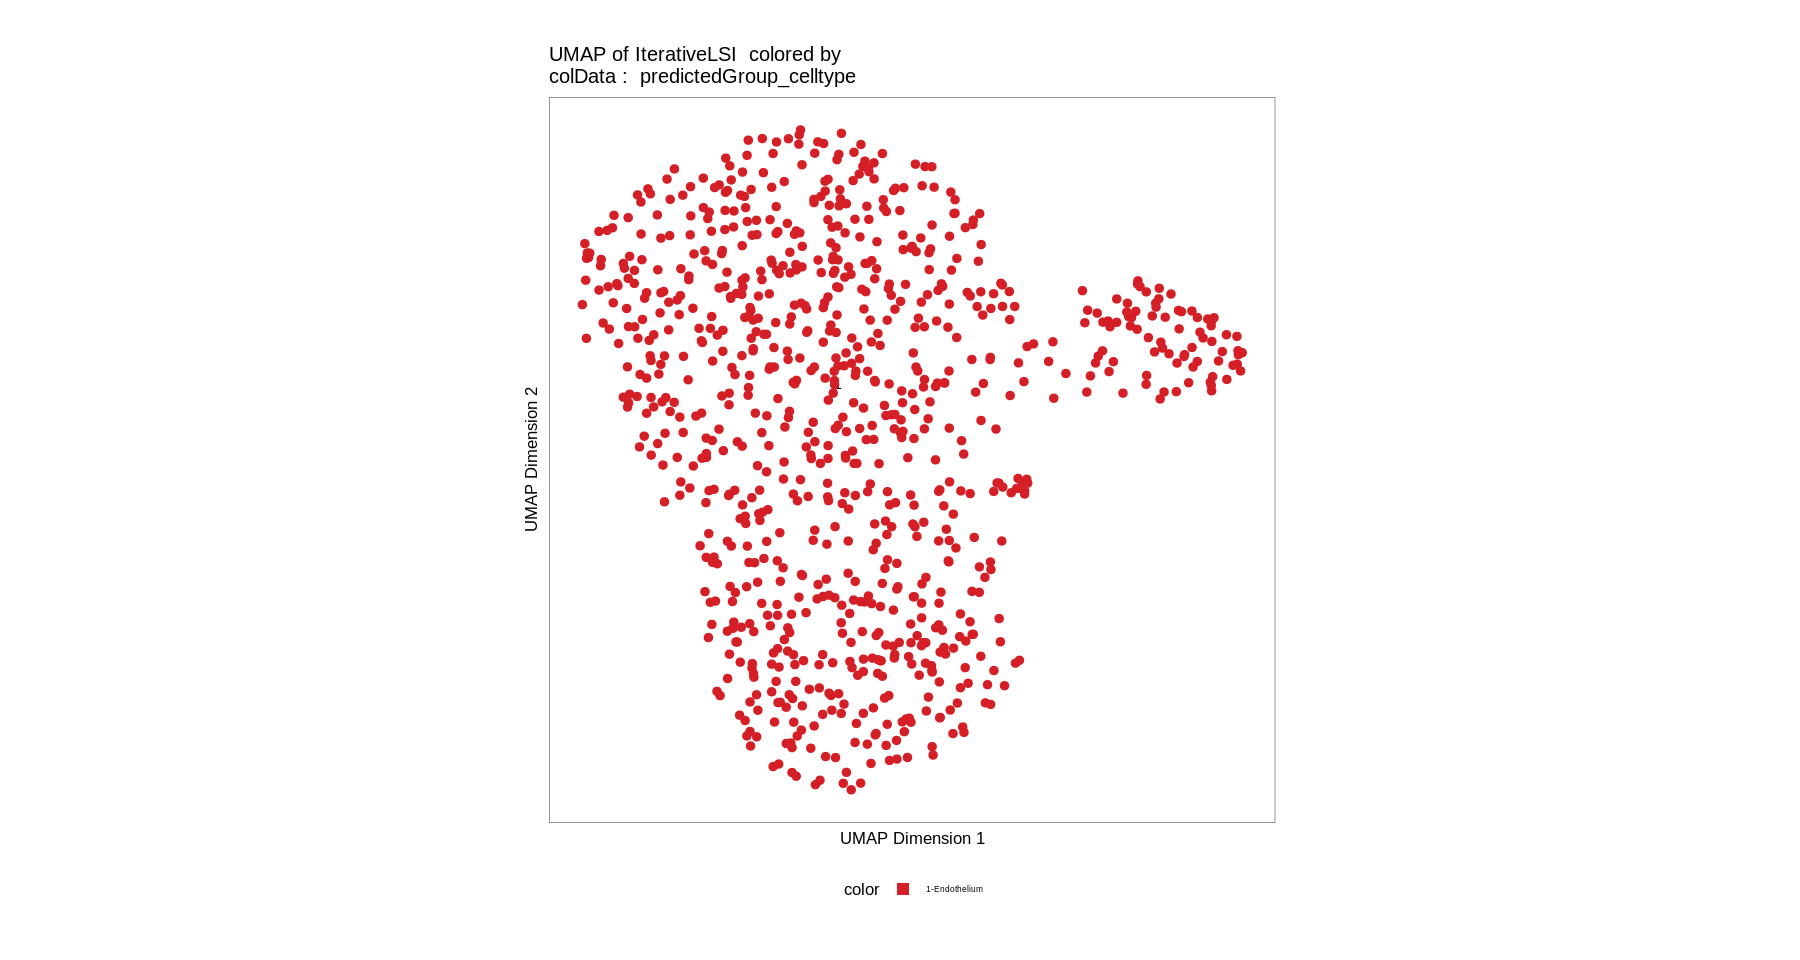

In [74]:
plotEmbedding(endo, colorBy = "cellColData", name = "predictedGroup_celltype") + geom_point(size = 2)

In [75]:
### Integrate with other RNA annotation
rna_in = '/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/RNA/'
sceRNA = readRDS(file.path(rna_in, 'RangedSummarizedExperiment.rds'))

In [76]:
rna_in_old = '/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC/RNA/'
alt_meta = read.csv(file.path(rna_in_old, 'metadata.csv'))

In [77]:
rownames(alt_meta) = alt_meta$cell

In [78]:
summary(alt_meta$cell == colnames(sceRNA))

   Mode    TRUE 
logical  146133 

In [79]:
colData = SummarizedExperiment(colData = alt_meta)
sceRNA@colData = colData@colData

In [80]:
celltypes = c('Allantois endothelium', 'Embryo proper endothelium', 'Venous endothelium','YS endothelium')
RNA_endo = sceRNA[,colData(sceRNA)$celltype %in% celltypes] # for RangedSummarizedExperiment object

In [81]:
    # Integrate
    endo <- addGeneIntegrationMatrix(
        ArchRProj = endo, 
        useMatrix = "GeneScoreMatrix",
        matrixName = "GeneIntegrationMatrix",
       # reducedDims = "IterativeLSI_Harmony",
        reducedDims = "IterativeLSI",
        seRNA = RNA_endo,
        addToArrow = FALSE,
        force= TRUE,
        groupRNA = "celltype",
        nameCell = "predictedCell_Un",
        nameGroup = "predictedGroup_celltype",
        nameScore = "predictedScore_celltype")

ArchR logging to : ArchRLogs/ArchR-addGeneIntegrationMatrix-8b052c74053-Date-2021-12-16_Time-13-30-59.log
If there is an issue, please report to github with logFile!

2021-12-16 13:30:59 : Running Seurat's Integration Stuart* et al 2019, 0.003 mins elapsed.

2021-12-16 13:31:00 : Checking ATAC Input, 0.014 mins elapsed.

2021-12-16 13:31:00 : Checking RNA Input, 0.015 mins elapsed.

2021-12-16 13:31:03 : Found 20845 overlapping gene names from gene scores and rna matrix!, 0.069 mins elapsed.

2021-12-16 13:31:03 : Creating Integration Blocks, 0.069 mins elapsed.

2021-12-16 13:31:03 : Prepping Interation Data, 0.07 mins elapsed.

Filtering 20 dims correlated > 0.75 to log10(depth + 1)

2021-12-16 13:31:04 : Computing Integration in 1 Integration Blocks!, 0 mins elapsed.

2021-12-16 13:31:04 : Block (1 of 1) : Computing Integration, 0 mins elapsed.

2021-12-16 13:31:04 : Block (1 of 1) : Identifying Variable Genes, 0.005 mins elapsed.

2021-12-16 13:31:06 : Block (1 of 1) : Getting Gene

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-8b055a0b4be-Date-2021-12-16_Time-13-32-22.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-8b055a0b4be-Date-2021-12-16_Time-13-32-22.log



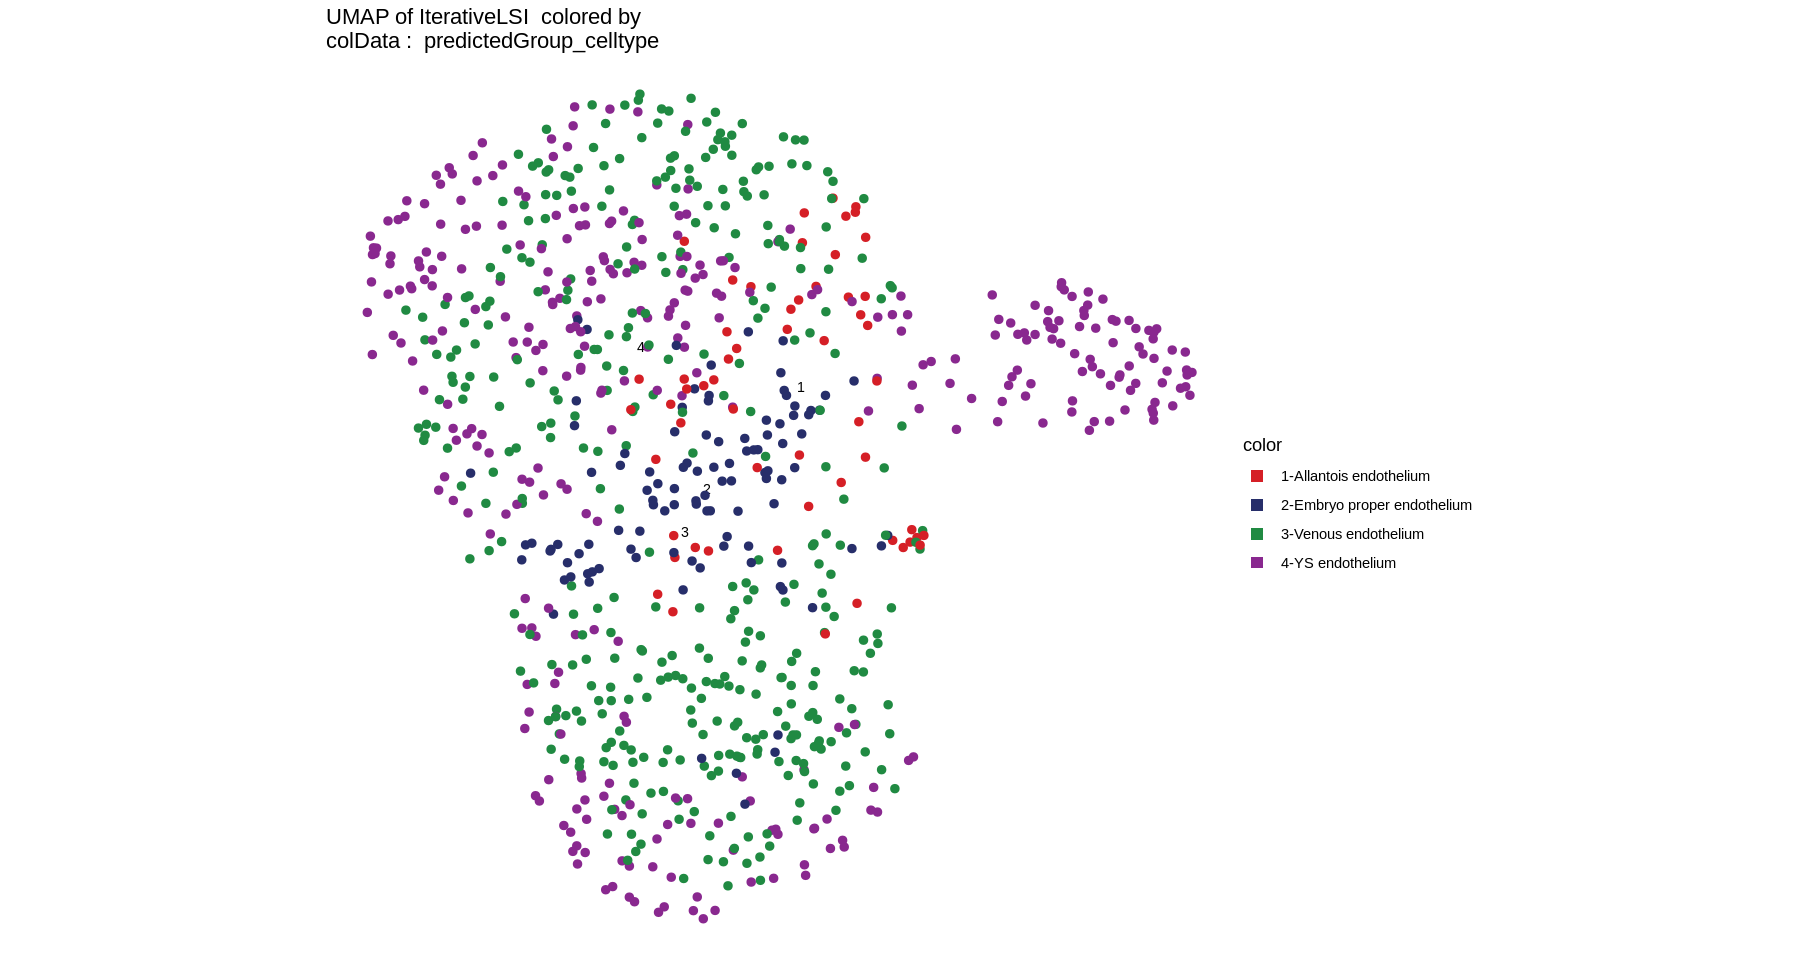

In [82]:
plotEmbedding(endo, colorBy = "cellColData", name = "predictedGroup_celltype") + geom_point(size = 2) + theme_void()

## Rerun endothelial & erythrocytes

In [98]:
keep = rownames(ArchRProject.filt@cellColData[ArchRProject.filt@cellColData$celltype_manual%in% c('Endothelium', 'Erythrocytes'),])
endo = ArchRProject.filt[keep]

Dropping ImputeWeights Since You Are Subsetting Cells! ImputeWeights is a cell-x-cell Matrix!



In [99]:
unique(ArchRProject.filt@cellColData$predictedGroup_celltype)

[1] "Anterior Hypoblast"             "Primitive Streak"              
 [3] "Epiblast"                       "Trophoblast"                   
 [5] "Hypoblast"                      "Haematoendothelial progenitors"
 [7] "Visceral YS Endoderm"           "NMP"                           
 [9] "EXE mesoderm"                   "SCT"                           
[11] "CYT"                            "Cardiomyocytes"                
[13] "Posterior Mesoderm"             "Brain/Neural Tube"             
[15] "Anterior Mesoderm"              "Somitic Mesoderm"              
[17] "Early Amniotic Ectoderm"        "Endothelium"                   
[19] "Early Erythrocytes"             "Late Erythrocytes"             
[21] "Megakaryocytes"                 "Allantois"                     
[23] "YS Mesothelium"                 "Cranial Mesoderm"              
[25] "Neural Crest"                   "Placodes"                      
[27] "Chorion"

In [100]:
endo


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(25): Clusters sample ... ReadsInPeaks FRIP
numberOfCells(1): 1973
medianTSS(1): 3.859
medianFrags(1): 22077

In [101]:
endo <- addIterativeLSI(
  ArchRProj = endo,
  useMatrix = 'TileMatrix', 
  name = "IterativeLSI", 
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = 2, 
  saveIterations = FALSE,
  varFeatures = 15000, 
  force = TRUE,
  dimsToUse = 1:10
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-8b02df328af-Date-2021-12-16_Time-13-47-59.log
If there is an issue, please report to github with logFile!

2021-12-16 13:48:00 : Computing Total Across All Features, 0.009 mins elapsed.

2021-12-16 13:48:02 : Computing Top Features, 0.045 mins elapsed.

###########
2021-12-16 13:48:03 : Running LSI (1 of 2) on Top Features, 0.067 mins elapsed.
###########

2021-12-16 13:48:03 : Creating Partial Matrix, 0.067 mins elapsed.

2021-12-16 13:48:30 : Computing LSI, 0.505 mins elapsed.

2021-12-16 13:48:37 : Identifying Clusters, 0.627 mins elapsed.

2021-12-16 13:48:39 : Identified 6 Clusters, 0.662 mins elapsed.

2021-12-16 13:48:39 : Creating Cluster Matrix on the total Group Features, 0.662 mins elapsed.

2021-12-16 13:49:38 : Computing Variable Features, 1.639 mins elapsed.

###########
2021-12-16 13:49:38 : Running LSI (2 of 2) on Variable Features, 1.642 mins elapsed.
###########

2021-12-16 13:49:38 : Creating Part

In [102]:
# Run UMAP
endo <- addUMAP(
  ArchRProj = endo, 
  #reducedDims = 'IterativeLSI_Harmony',
  reducedDims = 'IterativeLSI',
  name = "UMAP",
  metric = "cosine",
#  dimsToUse = 10,
  nNeighbors = 25, 
  minDist = 0.3, 
  seed = 42,
  saveModel = FALSE,
  force = TRUE
)

13:50:14 UMAP embedding parameters a = 0.9922 b = 1.112

13:50:14 Read 1973 rows and found 10 numeric columns

13:50:14 Using Annoy for neighbor search, n_neighbors = 25

13:50:14 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

13:50:14 Writing NN index file to temp file /tmp/RtmpfBg2lq/file8b07ac8c2cd

13:50:14 Searching Annoy index using 16 threads, search_k = 2500

13:50:14 Annoy recall = 100%

13:50:15 Commencing smooth kNN distance calibration using 16 threads

13:50:17 Initializing from normalized Laplacian + noise

13:50:17 Commencing optimization for 500 epochs, with 67640 positive edges

13:50:24 Optimization finished



ArchR logging to : ArchRLogs/ArchR-plotEmbedding-8b07e07d1cb-Date-2021-12-16_Time-13-50-24.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-8b07e07d1cb-Date-2021-12-16_Time-13-50-24.log



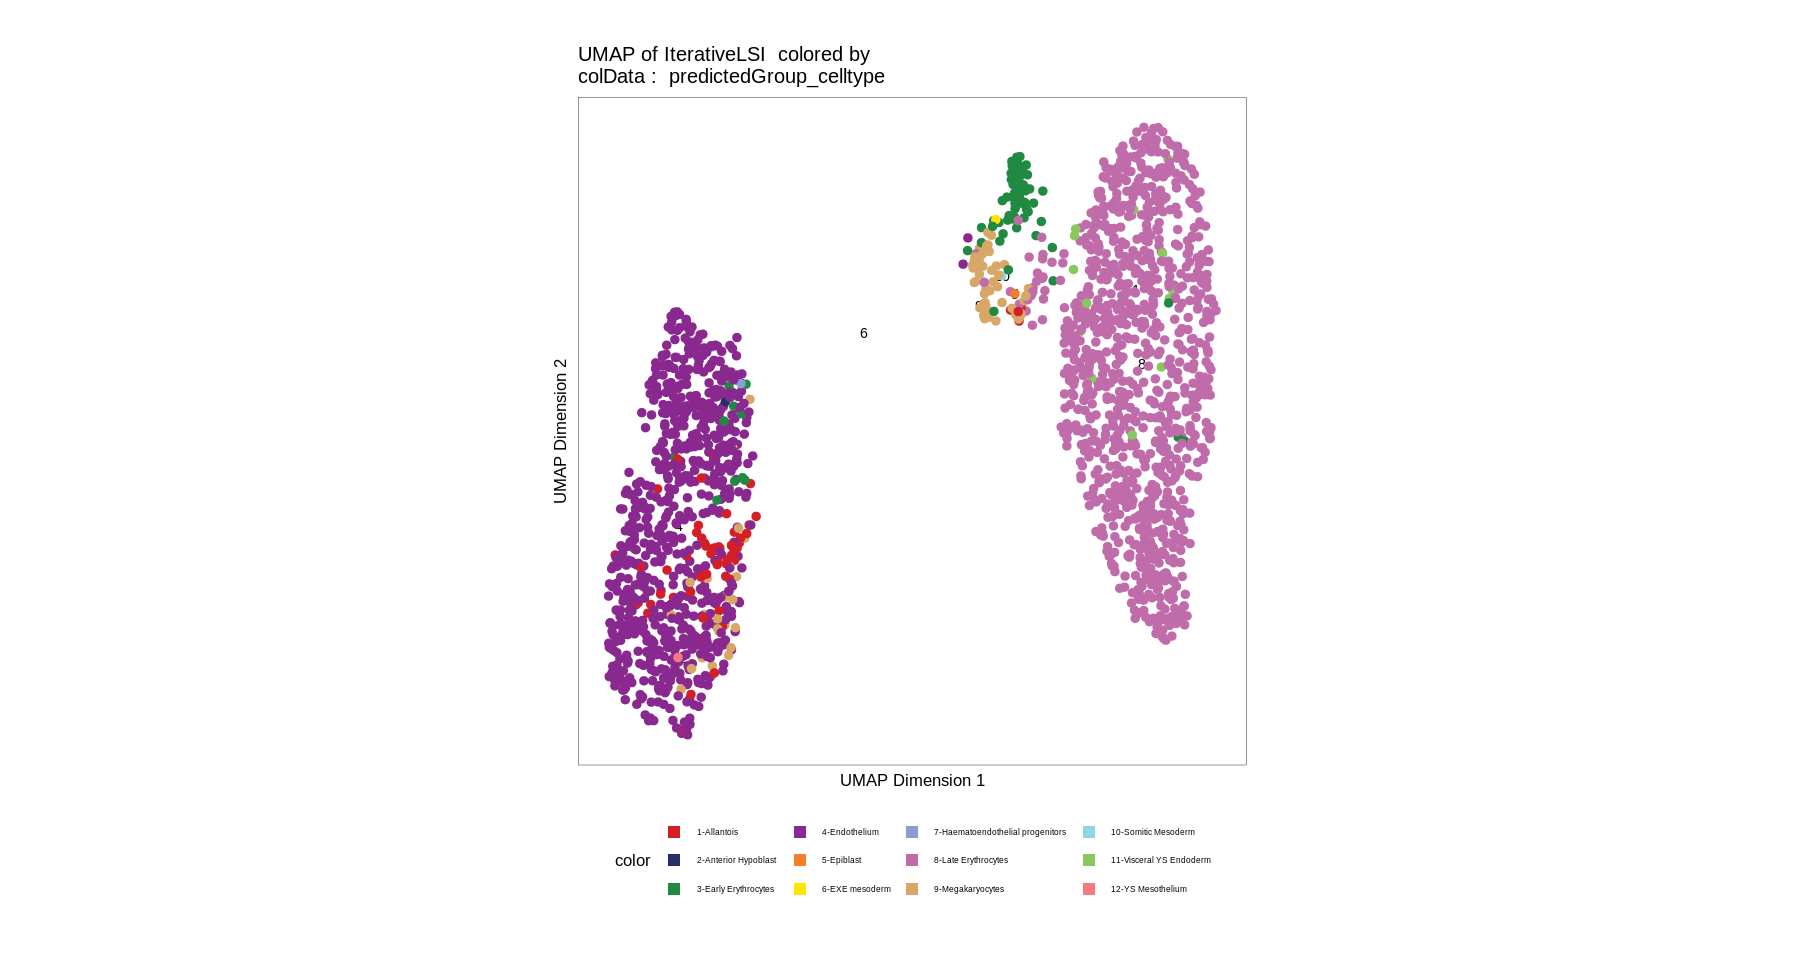

In [103]:
plotEmbedding(endo, colorBy = "cellColData", name = "predictedGroup_celltype") + geom_point(size = 2)

In [104]:
### Integrate with other RNA annotation
rna_in = '/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/RNA/'
sceRNA = readRDS(file.path(rna_in, 'RangedSummarizedExperiment.rds'))

In [105]:
rna_in_old = '/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC/RNA/'
alt_meta = read.csv(file.path(rna_in_old, 'metadata.csv'))

In [106]:
rownames(alt_meta) = alt_meta$cell

In [107]:
summary(alt_meta$cell == colnames(sceRNA))

   Mode    TRUE 
logical  146133 

In [108]:
colData = SummarizedExperiment(colData = alt_meta)
sceRNA@colData = colData@colData

In [109]:
celltypes = c('Allantois endothelium', 'Embryo proper endothelium', 'Venous endothelium','YS endothelium', 'Erythroid')
RNA_endo = sceRNA[,colData(sceRNA)$celltype %in% celltypes] # for RangedSummarizedExperiment object

In [110]:
unique(sceRNA@colData$celltype)

[1] "Epiblast"                             
 [2] "Hypoblast"                            
 [3] "Cytotrophoblast"                      
 [4] "Caudal mesoderm"                      
 [5] "Trophoblast"                          
 [6] "Unknown"                              
 [7] "Primitive Streak"                     
 [8] "PGC"                                  
 [9] "Allantois endothelium"                
[10] "Pharyngeal endoderm"                  
[11] "Visceral endoderm"                    
[12] "Lateral plate mesoderm"               
[13] "Embryo proper endothelium"            
[14] "Amniotic ectoderm"                    
[15] "Parietal endoderm"                    
[16] "Gut tube"                             
[17] "Non-neural ectoderm 2"                
[18] "EMP"                                  
[19] "Node"                                 
[20] "Syncytiotrophoblast progenitors"      
[21] "Notochord"                            
[22] "Dermomyotome"                         
[23] "MEP"                                  
[24] "Posterior somitic tissues"            
[25] "Presomitic mesoderm"                  
[26] "Mesenchyme"                           
[27] "Anterior somitic tissues"             
[28] "Anterior cardiopharyngeal progenitors"
[29] "Cardiomyocytes FHF 1"                 
[30] "Syncytiotrophoblast"                  
[31] "Venous endothelium"                   
[32] "Non-neural ectoderm 1"                
[33] "Erythroid"                            
[34] "Endocardium"                          
[35] "Hindbrain/Spinal cord"                
[36] "Limb mesoderm"                        
[37] "Mesothelium"                          
[38] "NMPs/Mesoderm-biased"                 
[39] "NMPs"                                 
[40] "Cardiomyocytes FHF 2"                 
[41] "Sclerotome"                           
[42] "YS endothelium"                       
[43] "Forebrain/Eye"                        
[44] "Somitic mesoderm"                     
[45] "Otic placode"                         
[46] "Cardiopharyngeal progenitors"         
[47] "Allantois"                            
[48] "Midgut"                               
[49] "Non-neural ectoderm 4"                
[50] "Neural tube"                          
[51] "Non-neural ectoderm 3"                
[52] "Floor plate"                          
[53] "Differentiating neurons"              
[54] "Thyroid primordium"                   
[55] "Nephron progenitors"                  
[56] "Epicardium"                           
[57] "EPDC"                                 
[58] "Cranial neural crest"                 
[59] "Cranial mesoderm"                     
[60] "Migratory neural crest"               
[61] "Megakariocytes"

In [111]:
    # Integrate
    endo <- addGeneIntegrationMatrix(
        ArchRProj = endo, 
        useMatrix = "GeneScoreMatrix",
        matrixName = "GeneIntegrationMatrix",
       # reducedDims = "IterativeLSI_Harmony",
        reducedDims = "IterativeLSI",
        seRNA = RNA_endo,
        addToArrow = FALSE,
        force= TRUE,
        groupRNA = "celltype",
        nameCell = "predictedCell_Un",
        nameGroup = "predictedGroup_celltype",
        nameScore = "predictedScore_celltype")

ArchR logging to : ArchRLogs/ArchR-addGeneIntegrationMatrix-8b04a8baa91-Date-2021-12-16_Time-13-51-13.log
If there is an issue, please report to github with logFile!

2021-12-16 13:51:13 : Running Seurat's Integration Stuart* et al 2019, 0.004 mins elapsed.

2021-12-16 13:51:15 : Checking ATAC Input, 0.033 mins elapsed.

2021-12-16 13:51:15 : Checking RNA Input, 0.033 mins elapsed.

2021-12-16 13:51:20 : Found 20845 overlapping gene names from gene scores and rna matrix!, 0.12 mins elapsed.

2021-12-16 13:51:20 : Creating Integration Blocks, 0.12 mins elapsed.

2021-12-16 13:51:20 : Prepping Interation Data, 0.122 mins elapsed.

Filtering 20 dims correlated > 0.75 to log10(depth + 1)

2021-12-16 13:51:21 : Computing Integration in 1 Integration Blocks!, 0 mins elapsed.

2021-12-16 13:51:21 : Block (1 of 1) : Computing Integration, 0 mins elapsed.

2021-12-16 13:51:23 : Block (1 of 1) : Identifying Variable Genes, 0.025 mins elapsed.

2021-12-16 13:51:25 : Block (1 of 1) : Getting GeneS

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-8b03368d992-Date-2021-12-16_Time-13-53-32.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-8b03368d992-Date-2021-12-16_Time-13-53-32.log



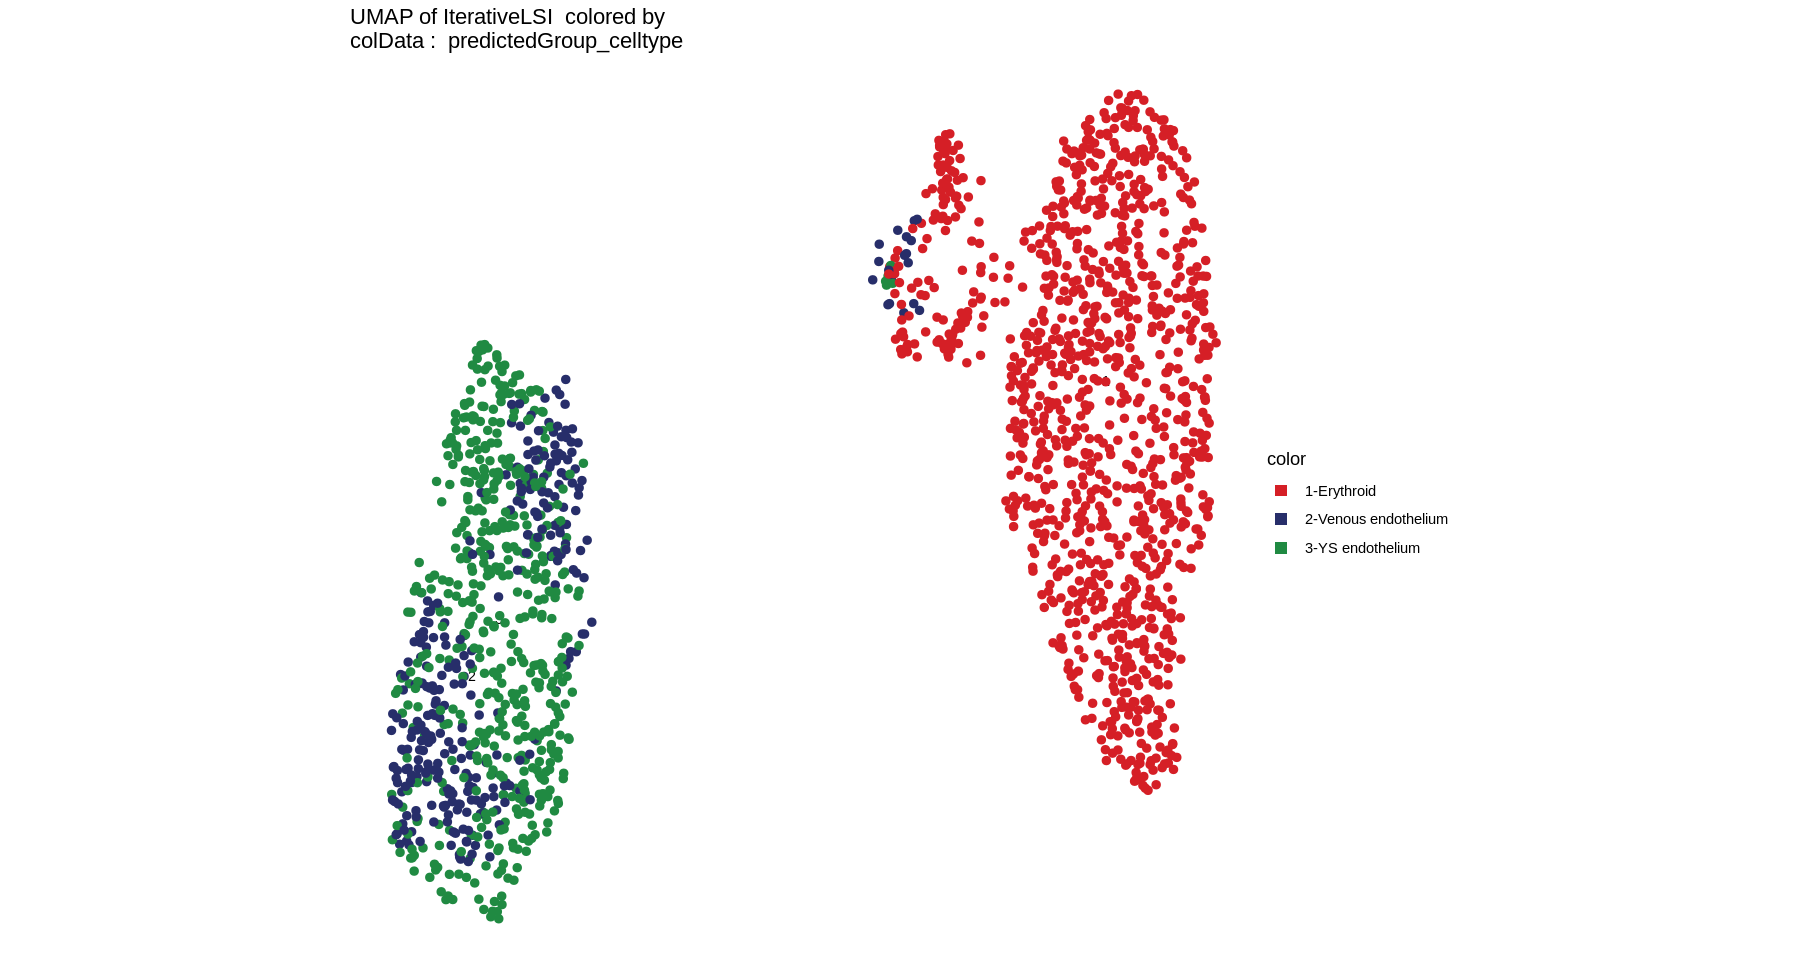

In [112]:
plotEmbedding(endo, colorBy = "cellColData", name = "predictedGroup_celltype") + geom_point(size = 2) + theme_void()

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-8b0140fcd0c-Date-2021-12-16_Time-13-58-09.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-8b0140fcd0c-Date-2021-12-16_Time-13-58-09.log



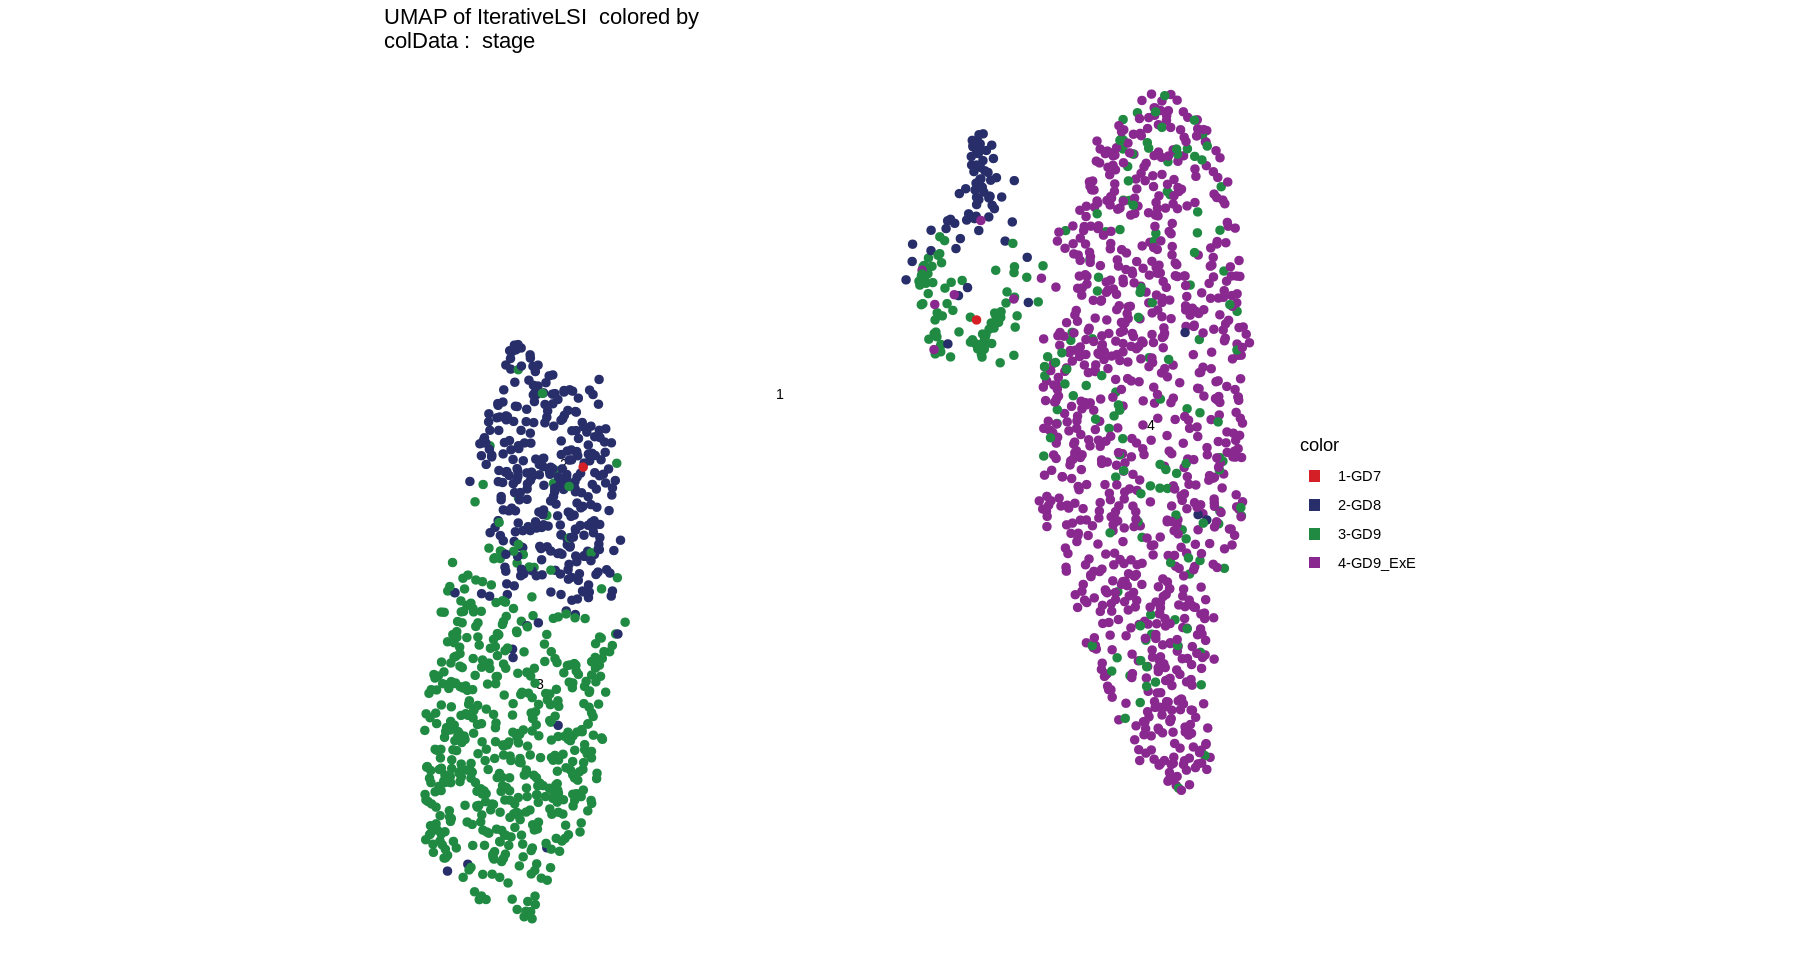

In [113]:
plotEmbedding(endo, colorBy = "cellColData", name = "stage") + geom_point(size = 2) + theme_void()

# Erythrocytes reclustering

In [114]:
keep = rownames(ArchRProject.filt@cellColData[ArchRProject.filt@cellColData$celltype_manual%in% c('Erythrocytes'),])
ery = ArchRProject.filt[keep]

Dropping ImputeWeights Since You Are Subsetting Cells! ImputeWeights is a cell-x-cell Matrix!



In [115]:
unique(ArchRProject.filt@cellColData$predictedGroup_celltype)

[1] "Anterior Hypoblast"             "Primitive Streak"              
 [3] "Epiblast"                       "Trophoblast"                   
 [5] "Hypoblast"                      "Haematoendothelial progenitors"
 [7] "Visceral YS Endoderm"           "NMP"                           
 [9] "EXE mesoderm"                   "SCT"                           
[11] "CYT"                            "Cardiomyocytes"                
[13] "Posterior Mesoderm"             "Brain/Neural Tube"             
[15] "Anterior Mesoderm"              "Somitic Mesoderm"              
[17] "Early Amniotic Ectoderm"        "Endothelium"                   
[19] "Early Erythrocytes"             "Late Erythrocytes"             
[21] "Megakaryocytes"                 "Allantois"                     
[23] "YS Mesothelium"                 "Cranial Mesoderm"              
[25] "Neural Crest"                   "Placodes"                      
[27] "Chorion"

In [116]:
ery


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(25): Clusters sample ... ReadsInPeaks FRIP
numberOfCells(1): 1124
medianTSS(1): 5.341
medianFrags(1): 16755.5

In [147]:
ery <- addIterativeLSI(
  ArchRProj = ery,
  useMatrix = 'TileMatrix', 
  name = "IterativeLSI", 
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = 4, 
  saveIterations = FALSE,
  varFeatures = 5000, 
  force = TRUE,
  dimsToUse = 1:12
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-8b019323398-Date-2021-12-16_Time-14-54-12.log
If there is an issue, please report to github with logFile!

2021-12-16 14:54:13 : Computing Total Across All Features, 0.008 mins elapsed.

2021-12-16 14:54:15 : Computing Top Features, 0.047 mins elapsed.

###########
2021-12-16 14:54:17 : Running LSI (1 of 4) on Top Features, 0.075 mins elapsed.
###########

2021-12-16 14:54:17 : Creating Partial Matrix, 0.076 mins elapsed.

2021-12-16 14:54:40 : Computing LSI, 0.453 mins elapsed.

2021-12-16 14:54:46 : Identifying Clusters, 0.564 mins elapsed.

2021-12-16 14:54:48 : Identified 6 Clusters, 0.588 mins elapsed.

2021-12-16 14:54:48 : Creating Cluster Matrix on the total Group Features, 0.588 mins elapsed.

2021-12-16 14:55:45 : Computing Variable Features, 1.541 mins elapsed.

###########
2021-12-16 14:55:45 : Running LSI (2 of 4) on Variable Features, 1.544 mins elapsed.
###########

2021-12-16 14:55:45 : Creating Part

In [144]:
ery <- addHarmony(
  ArchRProj = ery,
  reducedDims = "IterativeLSI",
  name = "IterativeLSI_Harmony",
  groupBy = 'stage',
  force = TRUE
)

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations



In [148]:
# Run UMAP
ery <- addUMAP(
  ArchRProj = ery, 
  reducedDims = 'IterativeLSI_Harmony',
  #reducedDims = 'IterativeLSI',
  name = "UMAP",
  metric = "cosine",
#  dimsToUse = 10,
  nNeighbors = 15, 
  minDist = 0.6, 
  seed = 42,
  saveModel = FALSE,
  force = TRUE
)

14:59:00 UMAP embedding parameters a = 0.4361 b = 1.447

14:59:00 Read 1124 rows and found 7 numeric columns

14:59:00 Using Annoy for neighbor search, n_neighbors = 15

14:59:00 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

14:59:01 Writing NN index file to temp file /tmp/RtmpfBg2lq/file8b04b660166

14:59:01 Searching Annoy index using 16 threads, search_k = 1500

14:59:01 Annoy recall = 100%

14:59:01 Commencing smooth kNN distance calibration using 16 threads

14:59:04 Initializing from normalized Laplacian + noise

14:59:04 Commencing optimization for 500 epochs, with 22208 positive edges

14:59:07 Optimization finished



ArchR logging to : ArchRLogs/ArchR-plotEmbedding-8b051edd44a-Date-2021-12-16_Time-14-59-07.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-8b051edd44a-Date-2021-12-16_Time-14-59-07.log



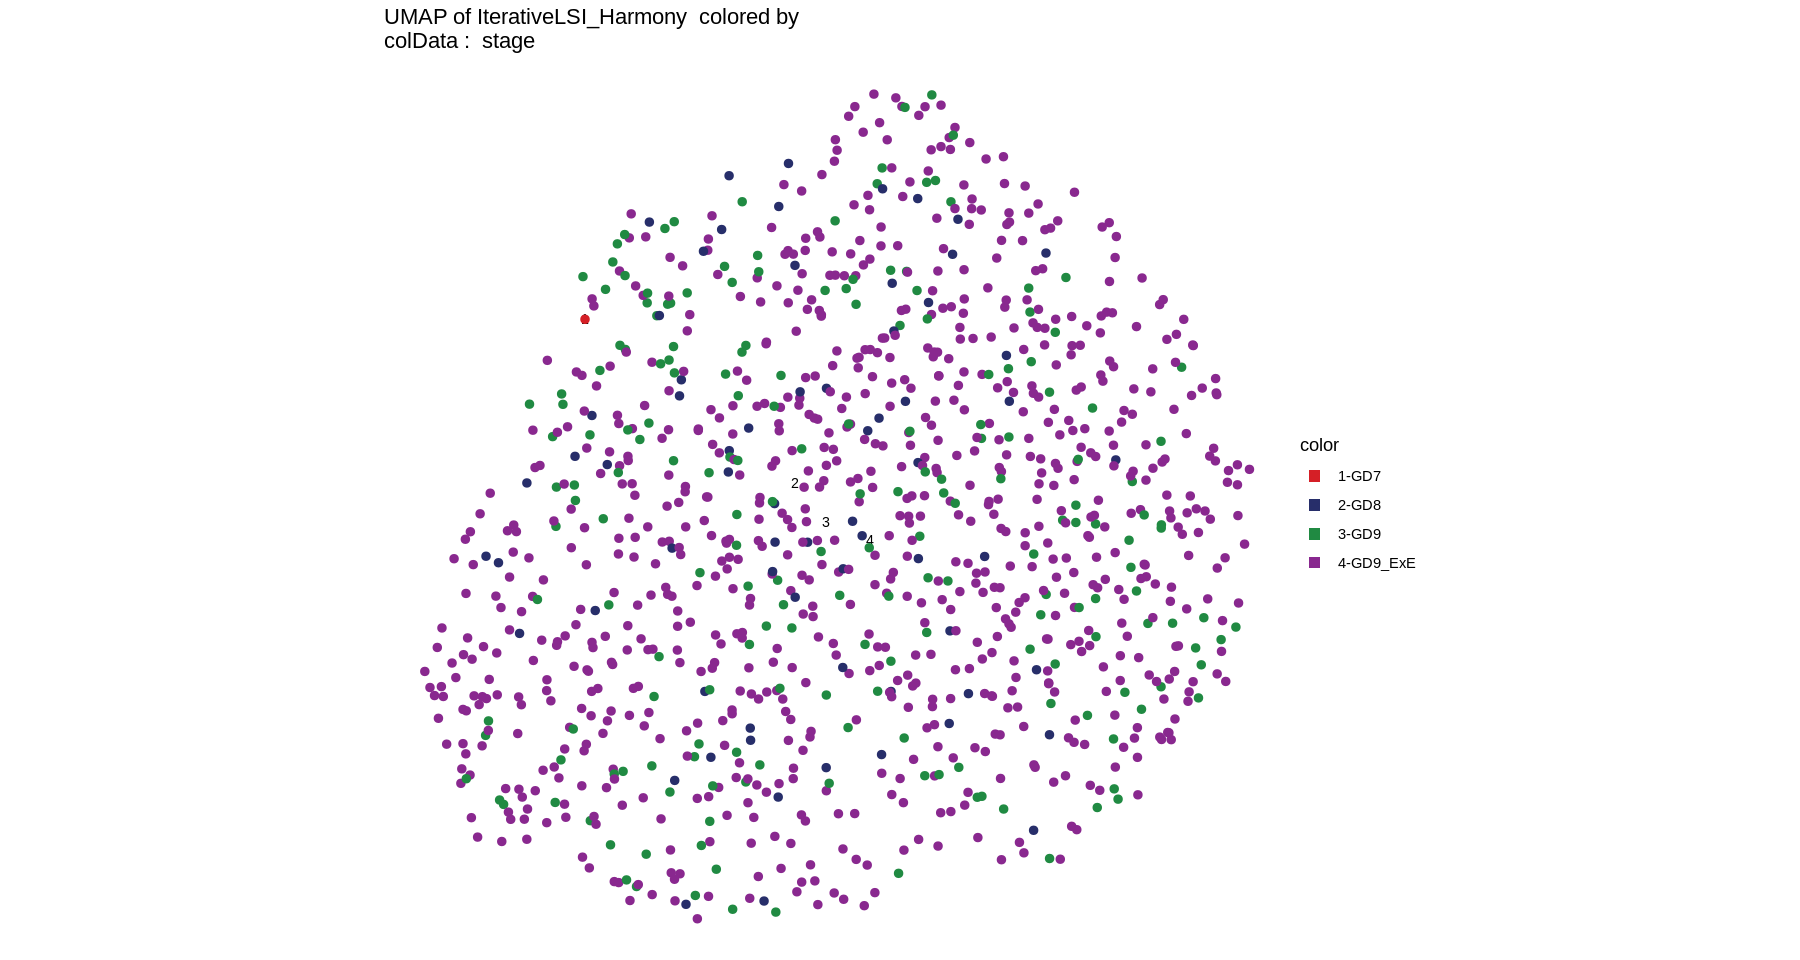

In [149]:
plotEmbedding(ery, colorBy = "cellColData", name = "stage") + geom_point(size = 2) + theme_void()

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-8b0156ef285-Date-2021-12-16_Time-14-52-51.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneScoreMatrix

Getting Matrix Values...

2021-12-16 14:52:52 : 

1 
2 
3 
4 
5 
6 
7 
8 


Imputing Matrix

Using weights on disk

1 of 1

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-8b0156ef285-Date-2021-12-16_Time-14-52-51.log



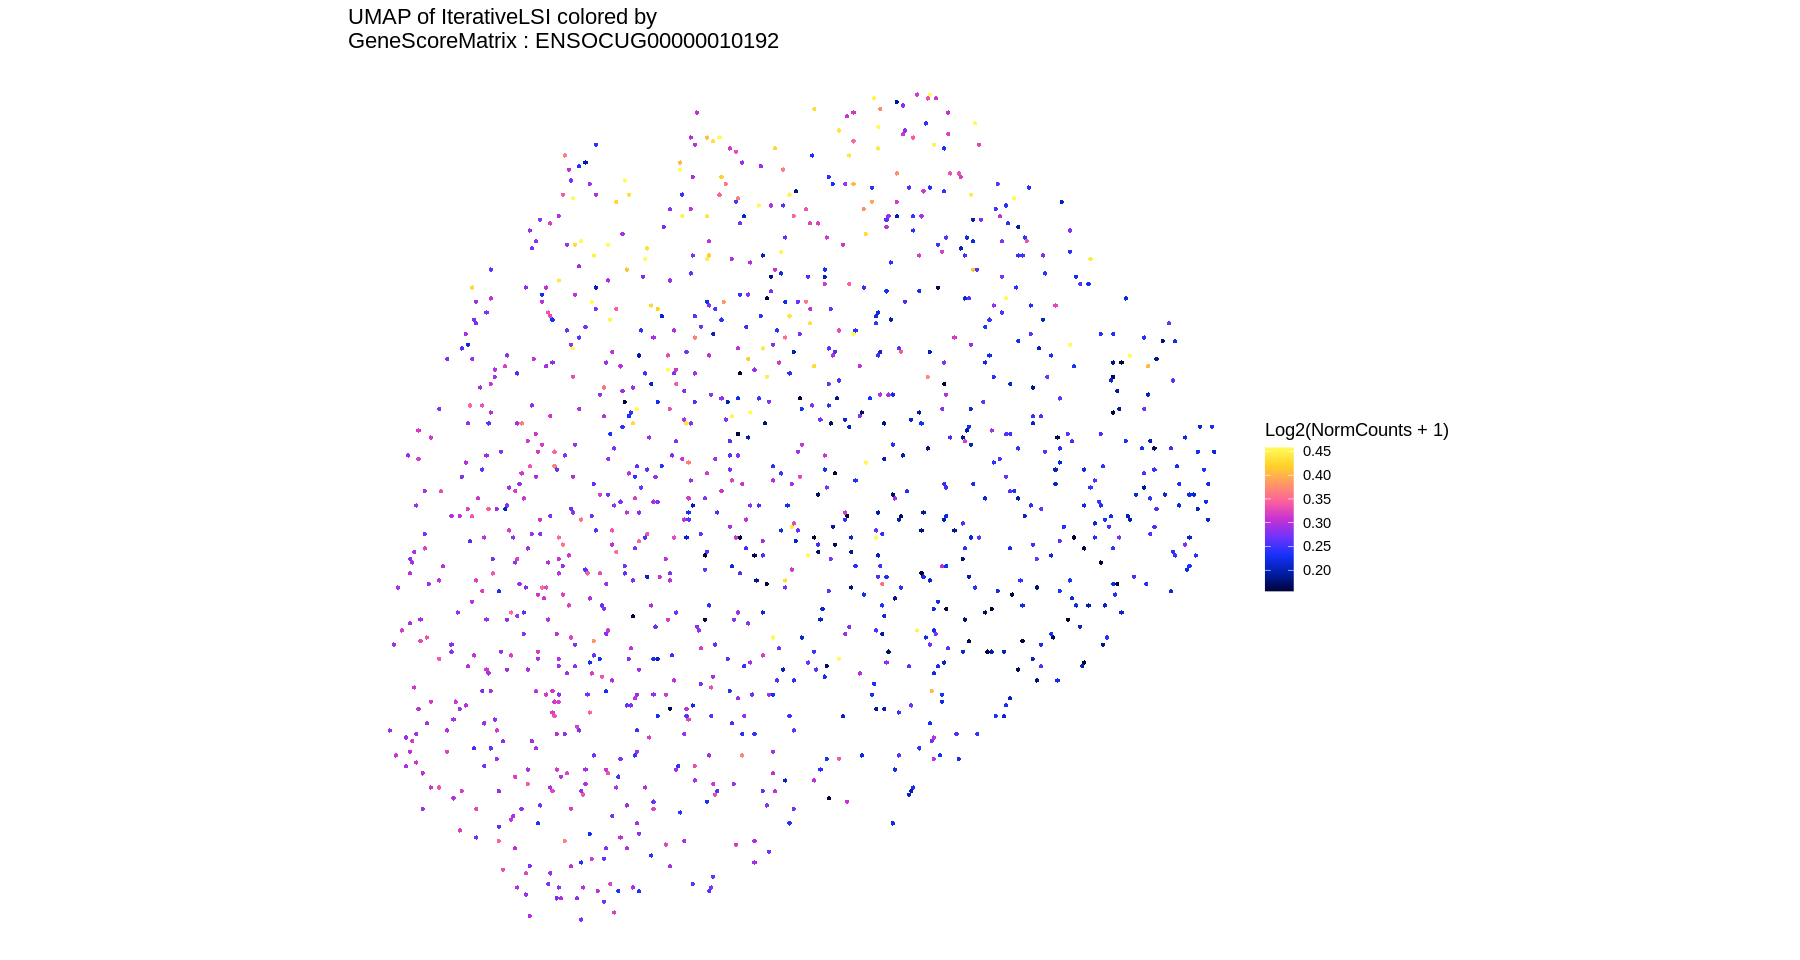

In [142]:
plotEmbedding(ery, colorBy = "GeneScoreMatrix", name = "ENSOCUG00000010192") + geom_point(size = 2) + theme_void()